# 01 - Data Prep Master
This notebook is the canonical data-preparation engine for the project. It: 
- Extracts global molecular descriptors and filters outliers
- Converts SMILES → PyG graphs with 3D coords and Gasteiger charges (same RDKit mol)
- Extracts structural pocket embeddings from 5 crystal structures
- Saves a unified PyG dataset at `data/processed/graph_data.pt`

In [10]:
# Cell 1: Imports & Global Settings
import os
import random
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from torch_geometric.data import Data
from rdkit import Chem
from rdkit.Chem import AllChem, rdPartialCharges, Descriptors, Crippen, rdMolDescriptors, Lipinski
from scipy.spatial import ConvexHull, distance_matrix
from Bio.PDB import PDBParser, NeighborSearch
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import logging
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Image
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

# Global paths
ROOT = Path.cwd().parent
DATA_RAW = ROOT / 'data' / 'raw'
PDB_DIR = DATA_RAW / 'pdb'
DATA_PROCESSED = ROOT / 'data' / 'processed'
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

# Deterministic seeds
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
# RDKit determinism via EmbedMolecule randomSeed when embedding

def show_saved_figure(fig_path):
    """Display a saved figure inline if it exists."""
    p = Path(fig_path)
    if p.exists():
        display(Image(filename=str(p)))

logging.basicConfig(level=logging.INFO)
print('Cell 1: imports, display helper, and seeds set (SEED=42)')

Cell 1: imports, display helper, and seeds set (SEED=42)


In [19]:
# Cell 2: Multi-Target PDB Pocket Extractor

# Ligand mapping for each PDB file (exact HETATM residue names)
PDB_LIGAND_MAP = {
    '1M17.pdb': 'AQ4',
    '2ITY.pdb': 'IRE',
    '3IKA.pdb': 'WZ4',
    '3W2S.pdb': 'GFT',
    '6LUD.pdb': '9KC',
}

# Explicit and deterministic target-to-PDB mapping configuration
PDB_ASSIGNMENT_CONFIG = {
    'column_candidates': ['PDB_ID', 'pdb_id', 'PDB', 'pdb', 'structure_id'],
    'default_pdb': '1M17.pdb',
    'allowed_pdbs': set(PDB_LIGAND_MAP.keys()),
}

WATER_RESNAMES = {'HOH', 'WAT', 'H2O', 'DOD'}

# Hand-tuned fallback centers only used if ligand atoms and non-water HETATM residues are missing.
# These are approximate active-site anchors so the extractor never collapses to all zeros.
ACTIVE_SITE_FALLBACK_CENTERS = {
    '1M17.pdb': np.array([14.8, 32.1, 28.4], dtype=np.float32),
    '2ITY.pdb': np.array([22.5, 18.6, 41.2], dtype=np.float32),
    '3IKA.pdb': np.array([26.1, 12.4, 19.7], dtype=np.float32),
    '3W2S.pdb': np.array([31.3, 24.8, 16.9], dtype=np.float32),
    '6LUD.pdb': np.array([18.9, 27.2, 35.5], dtype=np.float32),
}


def resolve_pdb_for_row(row, cfg=PDB_ASSIGNMENT_CONFIG):
    """Resolve a deterministic PDB assignment for one bioactivity row.

    Priority: explicit row annotation in known columns; fallback to configured default.
    """
    for col in cfg['column_candidates']:
        if col in row and pd.notna(row[col]):
            candidate = str(row[col]).strip()
            if candidate in cfg['allowed_pdbs']:
                return candidate
    return cfg['default_pdb']


def _count_hetatm_records(pdb_path, ligand_code):
    total_hetatm = 0
    matching_ligand = 0
    fallback_nonwater = 0
    candidate_resnames = []
    try:
        with open(pdb_path, 'r', encoding='utf-8', errors='ignore') as handle:
            for line in handle:
                if not line.startswith('HETATM'):
                    continue
                total_hetatm += 1
                resname = line[17:20].strip().upper()
                if resname and resname not in WATER_RESNAMES:
                    fallback_nonwater += 1
                    if resname not in candidate_resnames:
                        candidate_resnames.append(resname)
                if resname == ligand_code.upper():
                    matching_ligand += 1
    except Exception as exc:
        logging.warning(f'Could not scan HETATM records for {pdb_path}: {exc}')
    return total_hetatm, matching_ligand, fallback_nonwater, candidate_resnames


def _standardize_distance_signature(distance_signature, embedding_dim=128):
    if distance_signature.size == 0:
        return np.zeros(embedding_dim, dtype=np.float32)

    ordered = np.sort(distance_signature.astype(np.float32))
    if ordered.size == 1:
        ordered = np.repeat(ordered, embedding_dim)
    else:
        source_x = np.linspace(0.0, 1.0, num=ordered.size, dtype=np.float32)
        target_x = np.linspace(0.0, 1.0, num=embedding_dim, dtype=np.float32)
        ordered = np.interp(target_x, source_x, ordered).astype(np.float32)

    scaler = StandardScaler()
    standardized = scaler.fit_transform(ordered.reshape(-1, 1)).ravel().astype(np.float32)
    standardized = standardized - standardized.mean()
    standardized = standardized / (standardized.std() + 1e-8)
    return standardized.astype(np.float32)


def compute_pocket_tensor(pdb_path, ligand_code, cutoff=6.0, embedding_dim=128):
    """Distance-matrix based pocket extractor with debug logging and non-zero fallbacks.

    1) Count ligand HETATM records explicitly.
    2) Resolve a ligand atom set or a non-water HETATM fallback.
    3) Collect pocket atoms within cutoff.
    4) Use distances relative to the ligand centroid.
    5) Standardize and project to a fixed 128D embedding.
    """
    pdb_path = str(pdb_path)
    pdb_name = os.path.basename(pdb_path)
    total_hetatm, matching_ligand, fallback_nonwater, candidate_resnames = _count_hetatm_records(pdb_path, ligand_code)
    print(
        f'[{pdb_name}] HETATM total={total_hetatm} | '
        f'match({ligand_code})={matching_ligand} | '
        f'non-water HETATM={fallback_nonwater}'
    )

    parser = PDBParser(QUIET=True)
    structure = parser.get_structure(pdb_name, pdb_path)
    atom_list = list(structure.get_atoms())
    if len(atom_list) == 0:
        logging.warning(f'No atoms parsed from {pdb_path}; using active-site fallback center')
        fallback_center = ACTIVE_SITE_FALLBACK_CENTERS.get(pdb_name, np.zeros(3, dtype=np.float32))
        signature = np.linalg.norm(fallback_center.reshape(1, 3), axis=1).astype(np.float32)
        emb = _standardize_distance_signature(signature, embedding_dim=embedding_dim)
        return torch.tensor(emb, dtype=torch.float32)

    ligand_atoms = []
    ligand_resnames = []
    for res in structure.get_residues():
        try:
            resname = res.get_resname().strip().upper()
            if resname == ligand_code.upper():
                atoms = list(res.get_atoms())
                ligand_atoms.extend(atoms)
                if atoms and resname not in ligand_resnames:
                    ligand_resnames.append(resname)
        except Exception:
            continue

    if len(ligand_atoms) == 0:
        logging.warning(
            f'No ligand atoms found for {ligand_code} in {pdb_path}; '
            f'trying non-water HETATM fallback from {candidate_resnames[:5]}'
        )
        fallback_residue_atoms = []
        for res in structure.get_residues():
            try:
                resname = res.get_resname().strip().upper()
                if resname in WATER_RESNAMES:
                    continue
                if any(atom.get_parent().get_resname().strip().upper() in WATER_RESNAMES for atom in res.get_atoms()):
                    continue
                if res.get_id()[0].strip() != '':
                    fallback_residue_atoms.extend(list(res.get_atoms()))
                    break
            except Exception:
                continue
        if len(fallback_residue_atoms) > 0:
            ligand_atoms = fallback_residue_atoms
            ligand_resnames = sorted({atom.get_parent().get_resname().strip().upper() for atom in ligand_atoms})
            print(f'[{pdb_name}] fallback ligand residues={ligand_resnames[:5]} atom_count={len(ligand_atoms)}')
        else:
            fallback_center = ACTIVE_SITE_FALLBACK_CENTERS.get(pdb_name)
            if fallback_center is None:
                fallback_center = np.array([atom.get_coord() for atom in atom_list], dtype=np.float32).mean(axis=0)
            print(f'[{pdb_name}] using active-site center fallback={fallback_center.tolist()}')
            all_coords = np.array([atom.get_coord() for atom in atom_list], dtype=np.float32)
            if all_coords.size == 0:
                return torch.zeros(embedding_dim, dtype=torch.float32)
            relative_distances = np.linalg.norm(all_coords - fallback_center.reshape(1, 3), axis=1)
            emb = _standardize_distance_signature(relative_distances, embedding_dim=embedding_dim)
            return torch.tensor(emb, dtype=torch.float32)

    ligand_coords = np.array([atom.get_coord() for atom in ligand_atoms], dtype=np.float32)
    ligand_centroid = ligand_coords.mean(axis=0)
    print(f'[{pdb_name}] ligand centroid={np.round(ligand_centroid, 3).tolist()} | ligand atoms={len(ligand_atoms)}')

    ns = NeighborSearch(atom_list)
    nearby_atoms = []
    for latom in ligand_atoms:
        around = ns.search(latom.get_coord(), cutoff, level='A')
        nearby_atoms.extend(around)

    seen = set()
    pocket_atoms = []
    for atom in nearby_atoms:
        key = (atom.get_serial_number(), atom.get_name(), tuple(np.round(atom.get_coord(), 3)))
        if key in seen:
            continue
        seen.add(key)
        pocket_atoms.append(atom)

    if len(pocket_atoms) == 0:
        logging.warning(f'No pocket atoms found near ligand {ligand_code} in {pdb_path}; using centroid fallback')
        all_coords = np.array([atom.get_coord() for atom in atom_list], dtype=np.float32)
        if all_coords.size == 0:
            fallback_center = ACTIVE_SITE_FALLBACK_CENTERS.get(pdb_name, np.zeros(3, dtype=np.float32))
            emb = _standardize_distance_signature(np.linalg.norm(fallback_center.reshape(1, 3), axis=1), embedding_dim=embedding_dim)
            return torch.tensor(emb, dtype=torch.float32)
        relative_distances = np.linalg.norm(all_coords - ligand_centroid.reshape(1, 3), axis=1)
        emb = _standardize_distance_signature(relative_distances, embedding_dim=embedding_dim)
        return torch.tensor(emb, dtype=torch.float32)

    pocket_coords = np.array([atom.get_coord() for atom in pocket_atoms], dtype=np.float32)
    relative_distances = np.linalg.norm(pocket_coords - ligand_centroid.reshape(1, 3), axis=1)
    print(
        f'[{pdb_name}] pocket atoms={len(pocket_atoms)} | '
        f'rel-distance range=({relative_distances.min():.3f}, {relative_distances.max():.3f})'
    )

    emb = _standardize_distance_signature(relative_distances, embedding_dim=embedding_dim)
    return torch.tensor(emb, dtype=torch.float32)

print('Cell 2: pocket extractor + explicit PDB mapping config defined')

Cell 2: pocket extractor + explicit PDB mapping config defined


In [31]:
# Rendering imports for EDA
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
print('EDA plotting libraries loaded (matplotlib, seaborn)')

EDA plotting libraries loaded (matplotlib, seaborn)


In [2]:
# Cell 3: Bioactivity Loading, Canonical Target Normalization, EDA, & Index Integrity

OUT = ROOT / 'results' / 'figures'
OUT.mkdir(parents=True, exist_ok=True)

bio_csv = DATA_RAW / 'bioactivity' / 'egfr_full_standardized.csv'
if not bio_csv.exists():
    raise FileNotFoundError(f'Missing expected bioactivity CSV: {bio_csv}')

df_raw = pd.read_csv(bio_csv)
print(f'Loaded raw bioactivity table: {bio_csv.name} ({len(df_raw)} rows)')

def normalize_bioactivity_table(df_in):
    """Normalize SMILES + activity columns into canonical `Smiles` and `pIC50`."""
    df = df_in.copy()
    lower_to_col = {c.lower(): c for c in df.columns}

    # Canonical SMILES column
    smiles_candidates = ['smiles', 'canonical_smiles', 'canonical smiles']
    smiles_col = None
    for cand in smiles_candidates:
        if cand in lower_to_col:
            smiles_col = lower_to_col[cand]
            break
    if smiles_col is None:
        raise ValueError('No SMILES column found in bioactivity table')
    df.rename(columns={smiles_col: 'Smiles'}, inplace=True)
    df['Smiles'] = df['Smiles'].astype(str).str.strip()

    # Try direct pIC50/pChEMBL columns first
    direct_candidates = ['pic50', 'pchembl_value', 'pchembl', 'activity_pic50']
    pic50_col = None
    for cand in direct_candidates:
        if cand in lower_to_col:
            pic50_col = lower_to_col[cand]
            break

    if pic50_col is not None:
        df['pIC50'] = pd.to_numeric(df[pic50_col], errors='coerce')
    else:
        # Derive from IC50 if needed: pIC50 = -log10(IC50[M]) = 9 - log10(IC50[nM])
        value_col = None
        for cand in ['standard_value', 'ic50', 'value', 'activity_value']:
            if cand in lower_to_col:
                value_col = lower_to_col[cand]
                break

        unit_col = None
        for cand in ['standard_units', 'units', 'unit']:
            if cand in lower_to_col:
                unit_col = lower_to_col[cand]
                break

        if value_col is None:
            df['pIC50'] = np.nan
        else:
            vals = pd.to_numeric(df[value_col], errors='coerce')
            if unit_col is not None:
                units = df[unit_col].astype(str).str.lower().str.strip()
                scale = np.where(units.isin(['nm', 'nanomolar']), 1.0,
                         np.where(units.isin(['um', 'micromolar', 'µm']), 1e3,
                         np.where(units.isin(['mm', 'millimolar']), 1e6, np.nan)))
                vals_nM = vals * scale
            else:
                # If units missing, treat as nM by convention for ChEMBL standard_value pipelines
                vals_nM = vals
            with np.errstate(divide='ignore', invalid='ignore'):
                df['pIC50'] = 9.0 - np.log10(vals_nM)

    # Clean impossible values
    df.loc[~np.isfinite(df['pIC50']), 'pIC50'] = np.nan
    return df

df_raw = normalize_bioactivity_table(df_raw)
print(f"Canonical columns ready: Smiles={df_raw['Smiles'].notna().sum()} rows, pIC50 non-null={df_raw['pIC50'].notna().sum()}")

def extract_global_features(smiles_list, pic50_list=None):
    rows = []
    for i, s in enumerate(smiles_list):
        mol = Chem.MolFromSmiles(s)
        if mol is None:
            rows.append({'SMILES': s})
            continue
        row = {
            'SMILES': s,
            'MolWt': Descriptors.MolWt(mol),
            'LogP': Crippen.MolLogP(mol),
            'NumHDonors': Descriptors.NumHDonors(mol),
            'NumHAcceptors': Descriptors.NumHAcceptors(mol),
            'TPSA': Descriptors.TPSA(mol),
            'RotatableBonds': Descriptors.NumRotatableBonds(mol),
        }
        if pic50_list is not None and i < len(pic50_list):
            row['pIC50'] = pic50_list[i]
        rows.append(row)
    return pd.DataFrame(rows)

pic50_list = df_raw['pIC50'].tolist()
df_global = extract_global_features(df_raw['Smiles'].tolist(), pic50_list)

from IPython.display import display
feature_cols = ['MolWt', 'LogP', 'NumHDonors', 'NumHAcceptors', 'TPSA', 'pIC50']
feature_cols = [c for c in feature_cols if c in df_global.columns]
if feature_cols:
    df_property = df_global[feature_cols].copy()
    summary = df_property.describe().T
    summary['missing'] = df_property.isna().sum()
    summary['nunique'] = df_property.nunique()
    summary['skew'] = df_property.skew(numeric_only=True)
    summary['kurtosis'] = df_property.kurtosis(numeric_only=True)
    print('Feature summary:')
    display(summary)

# Existing core EDA figures
def compute_lipinski(smiles_list):
    rows = []
    for s in smiles_list:
        m = Chem.MolFromSmiles(s)
        if m is None:
            continue
        rows.append({
            'SMILES': s,
            'Molecular Weight': Descriptors.MolWt(m),
            'LogP': Crippen.MolLogP(m),
            'NumHDonors': Descriptors.NumHDonors(m),
            'NumHAcceptors': Descriptors.NumHAcceptors(m),
        })
    return pd.DataFrame(rows)

desc_df = compute_lipinski(df_raw['Smiles'].tolist()[:500])
if len(desc_df) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    axes = axes.ravel()
    cols = ['Molecular Weight', 'LogP', 'NumHDonors', 'NumHAcceptors']
    lims = [500, 5, 5, 10]
    for i, c in enumerate(cols):
        axes[i].hist(desc_df[c].dropna(), bins=30, color='#3498db', edgecolor='black', alpha=0.7)
        axes[i].set_title(c)
        axes[i].axvline(lims[i], color='red', linestyle='--')
    plt.tight_layout()
    lip_out = OUT / 'lipinski_distributions.png'
    plt.savefig(lip_out, dpi=300, bbox_inches='tight')
    plt.close()
    print(f'Saved: {lip_out}')

# Fingerprint matrix used by additional EDA cells
sample_size = min(2000, len(df_raw))
sample_smiles = df_raw['Smiles'].sample(n=sample_size, random_state=SEED).tolist()
fps = []
valid_pic50 = []
for s in sample_smiles:
    m = Chem.MolFromSmiles(s)
    if m is None:
        continue
    fp = AllChem.GetMorganFingerprintAsBitVect(m, radius=2, nBits=1024)
    arr = np.array(list(fp.ToBitString()), dtype=np.int8)
    fps.append(arr)
    val = df_raw.loc[df_raw['Smiles'] == s, 'pIC50']
    valid_pic50.append(val.values[0] if len(val) > 0 else np.nan)

if fps:
    fp_array = np.stack(fps)
    pca2 = PCA(n_components=2)
    coords = pca2.fit_transform(fp_array)
    fig, ax = plt.subplots(figsize=(8, 6))
    pic = np.array(valid_pic50, dtype=float)
    mask = np.isfinite(pic)
    if mask.any():
        sc = ax.scatter(coords[mask, 0], coords[mask, 1], c=pic[mask], cmap='RdYlGn', s=26, edgecolors='none')
        plt.colorbar(sc, ax=ax, label='pIC50')
    if (~mask).any():
        ax.scatter(coords[~mask, 0], coords[~mask, 1], c='lightgray', s=18)
    ax.set_title('Chemical Space (PCA of Morgan fingerprints)')
    pca_out = OUT / 'chemical_space_pca.png'
    plt.tight_layout()
    plt.savefig(pca_out, dpi=300, bbox_inches='tight')
    plt.close()
    print(f'Saved: {pca_out}')

if 'pIC50' in df_global.columns:
    corr_cols = ['MolWt', 'LogP', 'NumHDonors', 'NumHAcceptors', 'pIC50']
    corr_cols = [c for c in corr_cols if c in df_global.columns]
    if len(corr_cols) > 1:
        corr = df_global[corr_cols].dropna().corr()
        fig, ax = plt.subplots(figsize=(6, 5))
        sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
        corr_out = OUT / 'descriptor_correlation_heatmap.png'
        plt.tight_layout()
        plt.savefig(corr_out, dpi=300, bbox_inches='tight')
        plt.close()
        print(f'Saved: {corr_out}')

    fig, ax = plt.subplots(figsize=(8, 5))
    sns.histplot(df_global['pIC50'].dropna(), bins=30, kde=True, color='#3498db', ax=ax)
    ax.set_title('pIC50 Bioactivity Distribution')
    pic_out = OUT / 'pic50_distribution.png'
    plt.tight_layout()
    plt.savefig(pic_out, dpi=300, bbox_inches='tight')
    plt.close()
    print(f'Saved: {pic_out}')

# Outlier removal with robust index integrity
outlier_cols = ['pIC50', 'MolWt', 'LogP', 'TPSA']
outlier_cols = [c for c in outlier_cols if c in df_global.columns]
keep_mask = pd.Series(True, index=df_global.index)
for col in outlier_cols:
    col_vals = pd.to_numeric(df_global[col], errors='coerce')
    Q1 = col_vals.quantile(0.25)
    Q3 = col_vals.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    keep_mask &= (col_vals >= lower) & (col_vals <= upper)

kept_indices = df_global.index[keep_mask].copy()
df_global = df_global.loc[kept_indices].reset_index(drop=True)
df = df_raw.loc[kept_indices].reset_index(drop=True)

print(f'Cell 3: Completed canonical normalization + EDA + IQR filtering: {len(df)} rows remain')

Loaded raw bioactivity table: egfr_full_standardized.csv (20933 rows)
Canonical columns ready: Smiles=20933 rows, pIC50 non-null=20933


[13:47:31] improperly formatted w block


Feature summary:


,count,mean,std,min,25%,50%,75%,max,missing,nunique,skew,kurtosis
MolWt,20909.0,485.237053,118.984268,110.112000,409.574,484.583000,557.706000,1452.395000,24,13034,0.843046,4.281174
LogP,20909.0,4.566682,1.422341,-5.994500,3.661,4.516300,5.452300,13.116500,24,13691,0.091533,1.006698
NumHDonors,20909.0,2.172414,1.230111,0.000000,1.000,2.000000,3.000000,24.000000,24,14,0.893297,6.435912
NumHAcceptors,20909.0,6.757425,2.189921,0.000000,5.000,7.000000,8.000000,20.000000,24,21,0.532630,1.923054
TPSA,20909.0,97.130424,30.006980,0.000000,79.380,97.500000,111.720000,684.850000,24,4368,1.299363,12.044597
pIC50,20909.0,7.022984,1.420691,1.259637,6.000,7.142668,8.154902,17.299989,24,3866,-0.204831,-0.424263


Saved: c:\Users\u2251865\Documents\u2251865\NSCLC_project\clean_data_diss\results\figures\lipinski_distributions.png


[13:47:41] DEPRECATION WARNING: please use MorganGenerator
[13:47:41] DEPRECATION WARNING: please use MorganGenerator
[13:47:41] DEPRECATION WARNING: please use MorganGenerator
[13:47:41] DEPRECATION WARNING: please use MorganGenerator
[13:47:41] DEPRECATION WARNING: please use MorganGenerator
[13:47:41] DEPRECATION WARNING: please use MorganGenerator
[13:47:41] DEPRECATION WARNING: please use MorganGenerator
[13:47:41] DEPRECATION WARNING: please use MorganGenerator
[13:47:41] DEPRECATION WARNING: please use MorganGenerator
[13:47:41] DEPRECATION WARNING: please use MorganGenerator
[13:47:41] DEPRECATION WARNING: please use MorganGenerator
[13:47:41] DEPRECATION WARNING: please use MorganGenerator
[13:47:41] DEPRECATION WARNING: please use MorganGenerator
[13:47:41] DEPRECATION WARNING: please use MorganGenerator
[13:47:41] DEPRECATION WARNING: please use MorganGenerator
[13:47:41] DEPRECATION WARNING: please use MorganGenerator
[13:47:41] DEPRECATION WARNING: please use MorganGenerat

Saved: c:\Users\u2251865\Documents\u2251865\NSCLC_project\clean_data_diss\results\figures\chemical_space_pca.png
Saved: c:\Users\u2251865\Documents\u2251865\NSCLC_project\clean_data_diss\results\figures\descriptor_correlation_heatmap.png
Saved: c:\Users\u2251865\Documents\u2251865\NSCLC_project\clean_data_diss\results\figures\pic50_distribution.png
Cell 3: Completed canonical normalization + EDA + IQR filtering: 19846 rows remain


In [33]:
# Cell 4: Feature inspection (separate cell)
from IPython.display import display
feature_cols = ['MolWt', 'LogP', 'NumHDonors', 'NumHAcceptors', 'TPSA', 'pIC50']
feature_cols = [c for c in feature_cols if c in df_global.columns]
if feature_cols:
    df_property = df_global[feature_cols].copy()
    summary = df_property.describe().T
    summary['missing'] = df_property.isna().sum()
    summary['nunique'] = df_property.nunique()
    summary['skew'] = df_property.skew(numeric_only=True)
    summary['kurtosis'] = df_property.kurtosis(numeric_only=True)
    print('Feature summary (describe().T):')
    display(summary)
    print('\nMissing values by feature:')
    display(df_property.isna().sum().sort_values(ascending=False).to_frame('missing'))
    print('\nFirst 10 rows of key descriptors:')
    display(df_property.head(10))
else:
    print('No numeric feature columns found for inspection')

Feature summary (describe().T):


,count,mean,std,min,25%,50%,75%,max,missing,nunique,skew,kurtosis
MolWt,19846.0,479.018273,99.747544,189.170000,410.438000,482.970000,554.401000,775.383000,0,12241,-0.196134,-0.379643
LogP,19846.0,4.571499,1.296094,1.007000,3.696615,4.522990,5.421360,8.135900,0,12869,0.075995,-0.176634
NumHDonors,19846.0,2.141943,1.151317,0.000000,1.000000,2.000000,3.000000,7.000000,0,8,0.372319,-0.057648
NumHAcceptors,19846.0,6.655749,1.908912,1.000000,5.000000,7.000000,8.000000,13.000000,0,13,-0.100573,-0.329763
TPSA,19846.0,95.121370,24.082231,32.260000,79.380000,97.275000,110.770000,159.930000,0,3974,-0.127167,-0.261276
pIC50,19846.0,7.079571,1.393615,2.853872,6.060481,7.197227,8.194839,11.221849,0,3699,-0.206151,-0.632752



Missing values by feature:


,missing
MolWt,0
LogP,0
NumHDonors,0
NumHAcceptors,0
TPSA,0
pIC50,0



First 10 rows of key descriptors:


,MolWt,LogP,NumHDonors,NumHAcceptors,TPSA,pIC50
0,383.814,4.45034,3.0,4.0,82.70,7.387216
1,482.903,3.61432,3.0,6.0,112.24,6.769551
2,369.432,4.77200,1.0,6.0,78.66,5.031517
3,283.287,2.31056,2.0,4.0,113.98,3.301030
4,215.168,1.73096,1.0,5.0,110.95,4.017729
5,539.999,3.22822,3.0,7.0,115.48,5.274905
6,249.222,1.40098,2.0,5.0,99.78,3.578396
7,236.234,1.55914,2.0,5.0,117.62,6.903090
8,542.015,3.57442,5.0,7.0,135.27,9.346787
9,200.201,1.51026,1.0,5.0,81.20,3.221849


In [34]:
# Cell 5: Drug-likeness evaluation (Lipinski's Rule of Five)
def evaluate_drug_likeness(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    mw = Descriptors.MolWt(mol)
    logp = Crippen.MolLogP(mol)
    hbd = Descriptors.NumHDonors(mol)
    hba = Descriptors.NumHAcceptors(mol)

    violations = 0
    if mw > 500:
        violations += 1
    if logp > 5:
        violations += 1
    if hbd > 5:
        violations += 1
    if hba > 10:
        violations += 1

    return {
        'MW': mw,
        'LogP': logp,
        'HBD': hbd,
        'HBA': hba,
        'RO5_Violations': violations,
    }

drug_likeness_data = []
for _, row in df_global.iterrows():
    r = evaluate_drug_likeness(row['SMILES'])
    if r is not None:
        drug_likeness_data.append(r)

drug_likeness_df = pd.DataFrame(drug_likeness_data)

print("DRUG-LIKENESS EVALUATION (Lipinski's Rule of Five)")
print('=' * 70)
print()

if len(drug_likeness_df) > 0:
    total = len(drug_likeness_df)
    counts = drug_likeness_df['RO5_Violations'].value_counts().sort_index()

    print('RO5 Violation Distribution:')
    for v in range(0, 5):
        n = int(counts.get(v, 0))
        pct = (100.0 * n / total) if total > 0 else 0.0
        status = '✓ PASS' if v <= 1 else '✗ FAIL'
        print(f'  {v} violation(s): {n:5d} molecules ({pct:5.1f}%) {status}')

    pass_count = int((drug_likeness_df['RO5_Violations'] <= 1).sum())
    fail_count = total - pass_count
    pass_pct = 100.0 * pass_count / total
    fail_pct = 100.0 * fail_count / total

    print()
    print(f'  Drug-like (≤1 violation): {pass_count} ({pass_pct:.1f}%)')
    print(f'  Non-drug-like (>1 violation): {fail_count} ({fail_pct:.1f}%)')
    print()

    print(f'Property Ranges ({total} molecules):')
    for label in ['MW', 'LogP', 'HBD', 'HBA']:
        s = pd.to_numeric(drug_likeness_df[label], errors='coerce').dropna()
        if len(s) == 0:
            continue
        mean = float(s.mean())
        std = float(s.std())
        mn = float(s.min())
        mx = float(s.max())
        print(f'  {label:<4}: {mean:6.1f} ± {std:5.1f}  (range: {mn:6.1f} – {mx:6.1f})')
else:
    print('No valid molecules for drug-likeness evaluation')

DRUG-LIKENESS EVALUATION (Lipinski's Rule of Five)

RO5 Violation Distribution:
  0 violation(s):  9055 molecules ( 45.6%) ✓ PASS
  1 violation(s):  5624 molecules ( 28.3%) ✓ PASS
  2 violation(s):  4987 molecules ( 25.1%) ✗ FAIL
  3 violation(s):   174 molecules (  0.9%) ✗ FAIL
  4 violation(s):     6 molecules (  0.0%) ✗ FAIL

  Drug-like (≤1 violation): 14679 (74.0%)
  Non-drug-like (>1 violation): 5167 (26.0%)

Property Ranges (19846 molecules):
  MW  :  479.0 ±  99.7  (range:  189.2 –  775.4)
  LogP:    4.6 ±   1.3  (range:    1.0 –    8.1)
  HBD :    2.1 ±   1.2  (range:    0.0 –    7.0)
  HBA :    6.7 ±   1.9  (range:    1.0 –   13.0)


Saved: c:\Users\u2251865\Documents\u2251865\NSCLC_project\clean_data_diss\results\figures\lipinski_distributions_reference_style.png


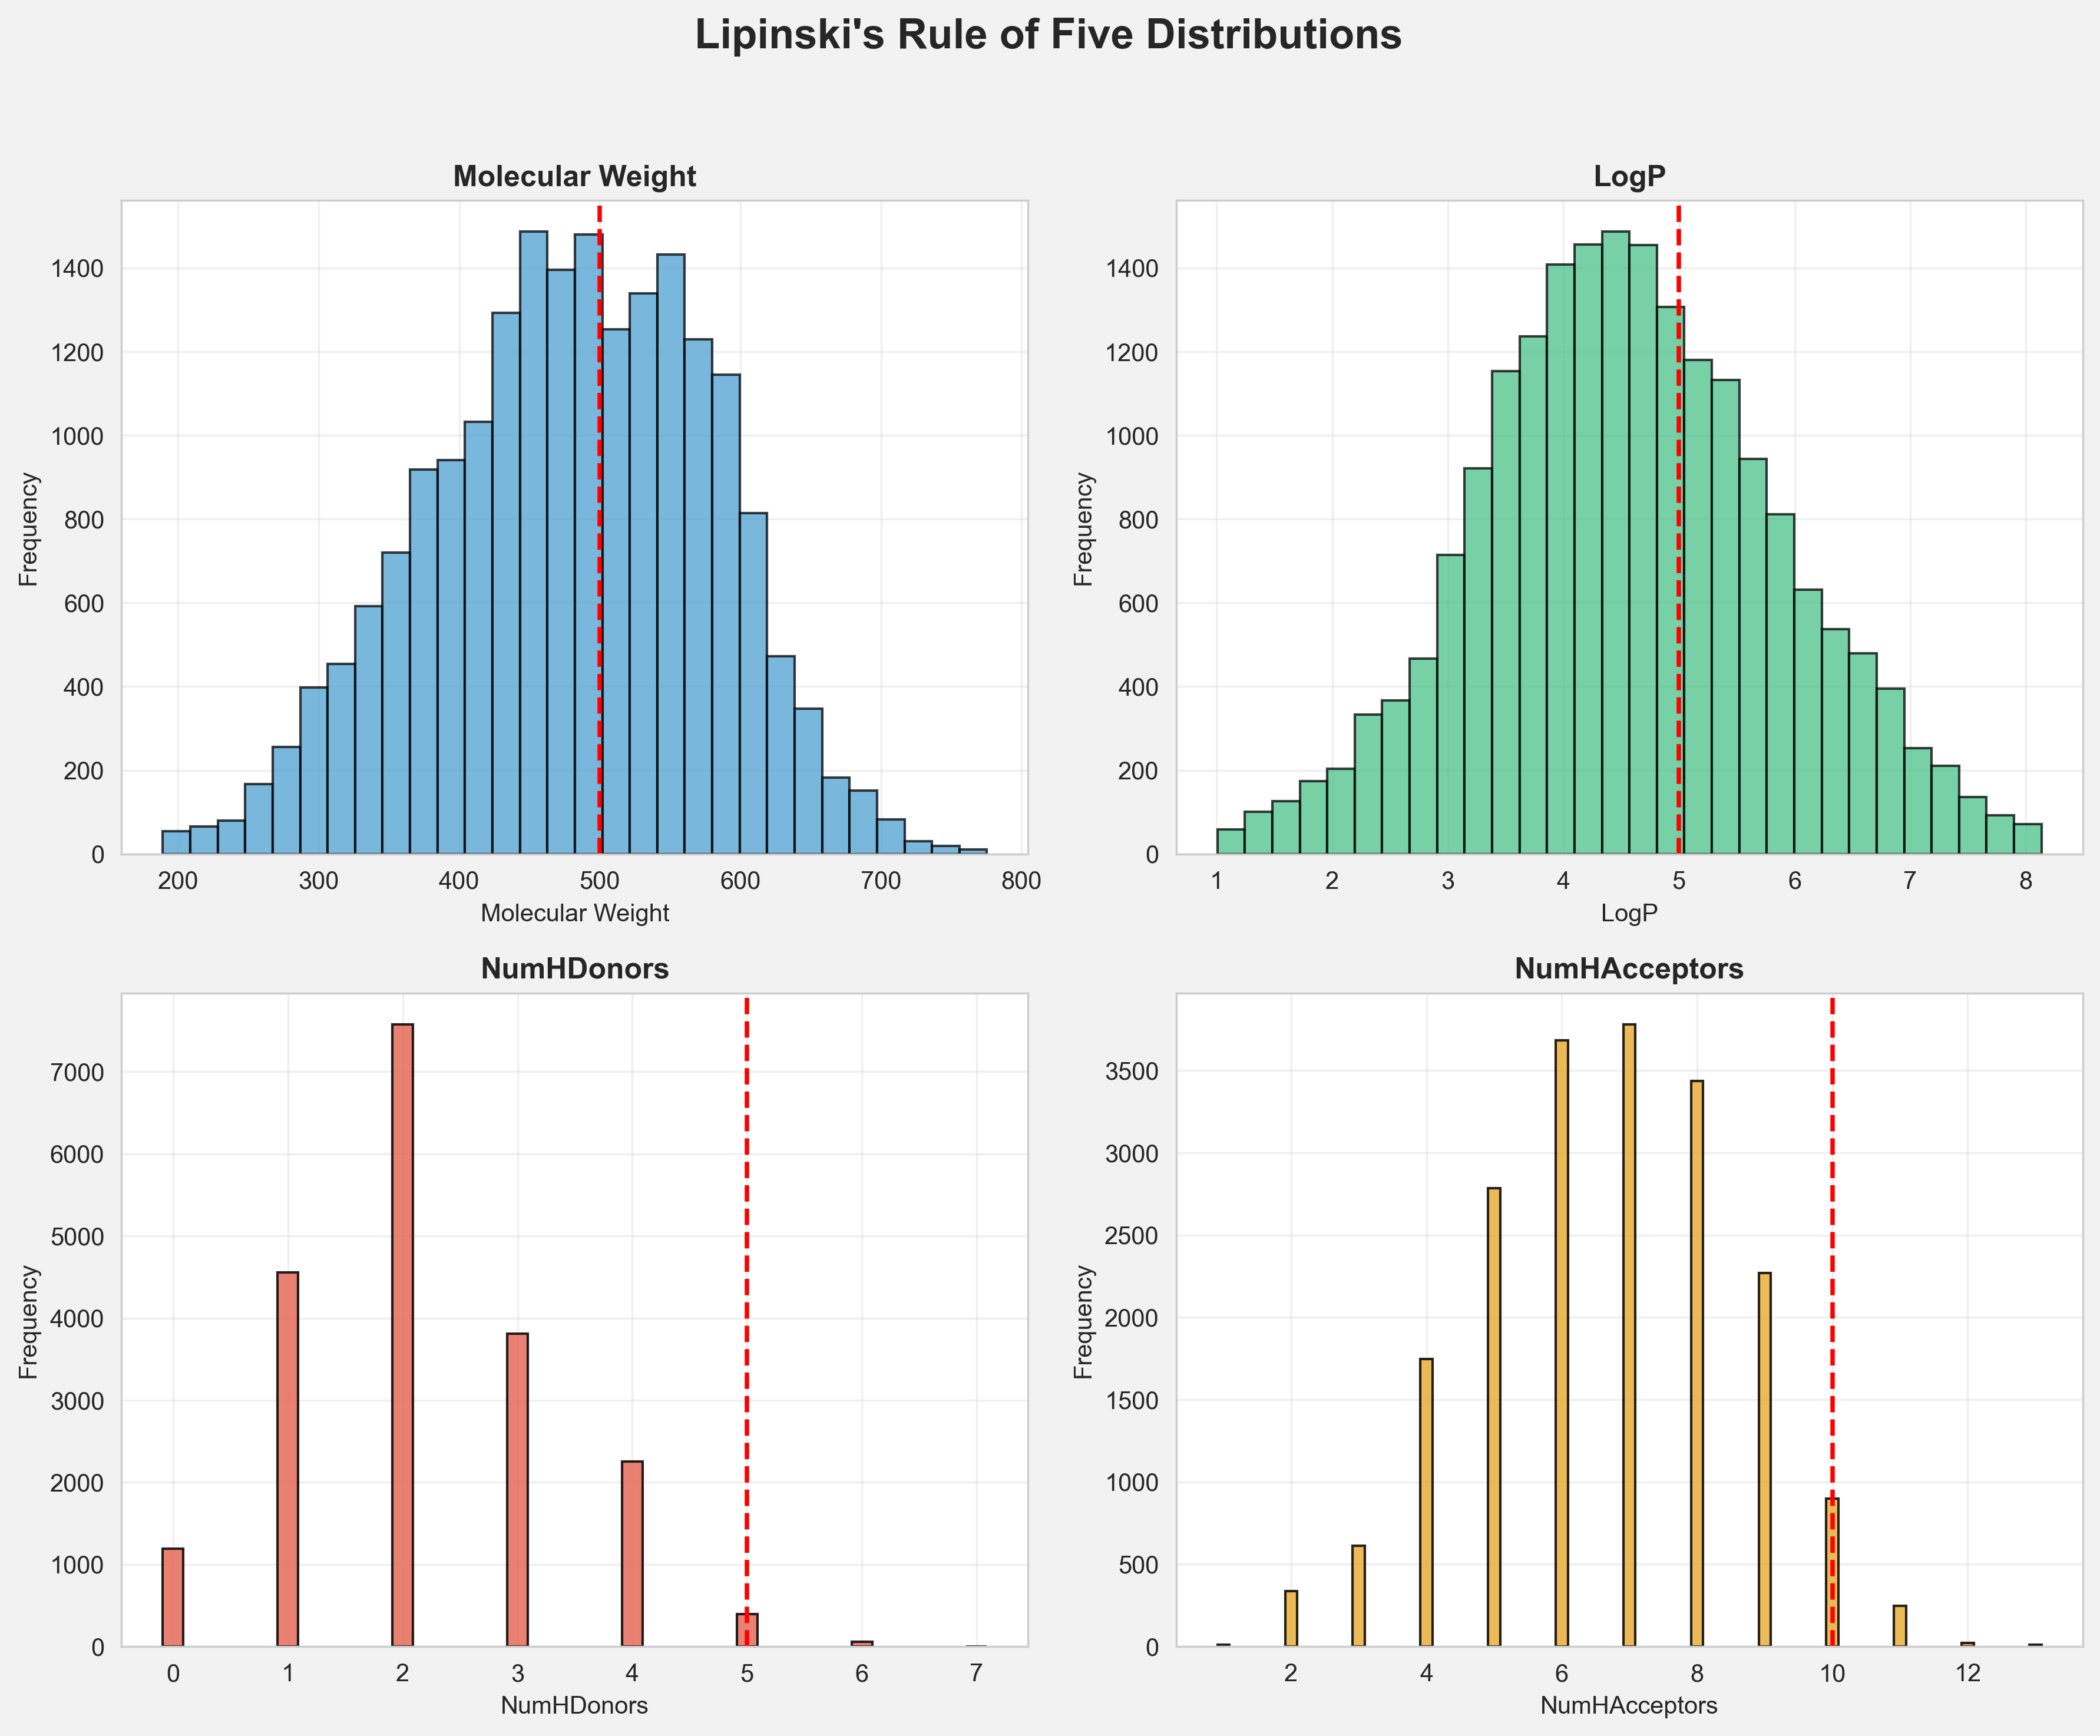

In [35]:
# Lipinski reference-style distribution figure (matches requested layout)
def compute_lipinski_plot_df(smiles_list):
    rows = []
    for s in smiles_list:
        m = Chem.MolFromSmiles(str(s))
        if m is None:
            continue
        rows.append({
            'Molecular Weight': Descriptors.MolWt(m),
            'LogP': Crippen.MolLogP(m),
            'NumHDonors': Descriptors.NumHDonors(m),
            'NumHAcceptors': Descriptors.NumHAcceptors(m),
        })
    return pd.DataFrame(rows)

source_smiles = df['Smiles'].astype(str).tolist() if 'Smiles' in df.columns else df_global['SMILES'].astype(str).tolist()
desc_df = compute_lipinski_plot_df(source_smiles)

if len(desc_df) == 0:
    print('No valid molecules available for Lipinski plotting')
else:
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.patch.set_facecolor('#f2f2f2')
    fig.suptitle("Lipinski's Rule of Five Distributions", fontsize=17, fontweight='bold')
    axes = axes.ravel()

    # Continuous histograms
    continuous_specs = [
        ('Molecular Weight', 500, '#4C9FD1'),
        ('LogP', 5, '#4BC288'),
    ]
    for i, (col, threshold, color) in enumerate(continuous_specs):
        ax = axes[i]
        vals = pd.to_numeric(desc_df[col], errors='coerce').dropna()
        ax.hist(vals, bins=30, color=color, edgecolor='black', alpha=0.75)
        ax.axvline(threshold, color='red', linestyle='--', linewidth=1.8)
        ax.set_title(col, fontweight='bold')
        ax.set_xlabel(col)
        ax.set_ylabel('Frequency')
        ax.grid(True, alpha=0.3)

    # Integer-count bar style for donors/acceptors
    discrete_specs = [
        ('NumHDonors', 5, '#E66B5B'),
        ('NumHAcceptors', 10, '#E9AE3A'),
    ]
    for j, (col, threshold, color) in enumerate(discrete_specs):
        ax = axes[j + 2]
        vals = pd.to_numeric(desc_df[col], errors='coerce').dropna().astype(int)
        counts = vals.value_counts().sort_index()
        ax.bar(counts.index, counts.values, width=0.18, color=color, edgecolor='black', alpha=0.85)
        ax.axvline(threshold, color='red', linestyle='--', linewidth=1.8)
        ax.set_title(col, fontweight='bold')
        ax.set_xlabel(col)
        ax.set_ylabel('Frequency')
        ax.grid(True, alpha=0.3)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    out_file = OUT / 'lipinski_distributions_reference_style.png'
    plt.savefig(out_file, dpi=300, bbox_inches='tight')
    plt.close(fig)
    print(f'Saved: {out_file}')
    show_saved_figure(out_file)

In [36]:
# Cell 6: Top 8 most potent compounds (2D grid + basic table)
from rdkit.Chem import Draw
try:
    import pubchempy as pcp
    HAS_PCP = True
except Exception:
    HAS_PCP = False

if 'pIC50' in df_global.columns and len(df_global) > 0:
    top_n = min(8, len(df_global))
    top_actives = df_global.nlargest(top_n, 'pIC50')
    mols_list = []
    legends = []
    chem_data = []
    for idx, row in top_actives.iterrows():
        m = Chem.MolFromSmiles(row['SMILES'])
        if m is None:
            continue
        mols_list.append(m)
        short_name = f"pIC50: {row['pIC50']:.2f}"
        if HAS_PCP:
            try:
                comps = pcp.get_compounds(row['SMILES'], namespace='smiles')
                if comps and comps[0].iupac_name:
                    short_name = comps[0].iupac_name.split(')')[-1][:20]
            except Exception:
                pass
        legends.append(short_name)
        chem_data.append({'pIC50': row.get('pIC50', float('nan')), 'MW': row.get('MolWt', float('nan')), 'LogP': row.get('LogP', float('nan')), 'SMILES': row['SMILES']})
    if mols_list:
        grid = Draw.MolsToGridImage(mols_list, molsPerRow=4, subImgSize=(200,200), legends=legends)
        out_file = OUT / 'top_actives_grid.png'
        # Save robustly for different RDKit/renderer return types
        try:
            if hasattr(grid, 'save'):
                grid.save(out_file)
            elif hasattr(grid, 'data'):
                # IPython.display.Image-like object
                with open(out_file, 'wb') as fh:
                    data = grid.data
                    if isinstance(data, str):
                        data = data.encode('utf-8')
                    fh.write(data)
            else:
                # Fallback: request PNG bytes from RDKit
                png = Draw.MolsToGridImage(mols_list, molsPerRow=4, subImgSize=(200,200), legends=legends, returnPNG=True)
                if isinstance(png, bytes):
                    with open(out_file, 'wb') as fh:
                        fh.write(png)
                else:
                    raise RuntimeError('Unknown image object; could not save')
            print(f'Saved top actives grid: {out_file}')
        except Exception as e:
            print('Failed to save top actives grid:', e)
        print('\nTop actives table:')
        for i, d in enumerate(chem_data, start=1):
            print(f"{i}. pIC50={d['pIC50']:.2f} | MW={d['MW']:.1f} | LogP={d['LogP']:.2f} | {d['SMILES'][:60]}")
    else:
        print('No valid molecules parsed for top actives')
else:
    print('Insufficient data for top actives visualization')

Saved top actives grid: c:\Users\u2251865\Documents\u2251865\NSCLC_project\clean_data_diss\results\figures\top_actives_grid.png

Top actives table:
1. pIC50=11.22 | MW=388.3 | LogP=4.93 | CCOc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OCC
2. pIC50=11.10 | MW=330.2 | LogP=3.57 | CNc1cc2c(Nc3cccc(Br)c3)ncnc2cn1
3. pIC50=11.10 | MW=340.2 | LogP=4.01 | Brc1cccc(Nc2ncnc3cc4[nH]cnc4cc23)c1
4. pIC50=11.10 | MW=562.7 | LogP=6.13 | COc1cc(N2CCC(N(C)C)CC2)ccc1Nc1ncc(C(=O)Oc2ccccc2)c(-c2c[nH]c
5. pIC50=11.10 | MW=340.2 | LogP=4.01 | Brc1cccc(Nc2ncnc3cc4nc[nH]c4cc23)c1
6. pIC50=11.05 | MW=467.5 | LogP=3.02 | COCCOc1cc2ncnc(Nc3cccc(OS(=O)(=O)F)c3)c2cc1OCCOC
7. pIC50=11.00 | MW=354.2 | LogP=4.02 | Cn1cnc2cc3ncnc(Nc4cccc(Br)c4)c3cc21
8. pIC50=11.00 | MW=354.2 | LogP=4.02 | Cn1cnc2cc3ncnc(Nc4cccc(Br)c4)c3cc12


In [37]:
# Cell 7: Descriptor correlation heatmap (separate cell)
if 'pIC50' in df_global.columns:
    corr_cols = ['MolWt', 'LogP', 'NumHDonors', 'NumHAcceptors', 'pIC50']
    corr_cols = [c for c in corr_cols if c in df_global.columns]
    if len(corr_cols) > 1:
        corr_mat = df_global[corr_cols].dropna().corr()
        fig, ax = plt.subplots(figsize=(6,5))
        sns.heatmap(corr_mat, annot=True, fmt='.3f', cmap='coolwarm', center=0, ax=ax)
        ax.set_title('Descriptor Correlation with pIC50')
        corr_out = OUT / 'descriptor_correlation_heatmap.png'
        plt.tight_layout(); plt.savefig(corr_out, dpi=300, bbox_inches='tight'); plt.close()
        print(f'Saved: {corr_out}')
        print('\nCorrelation with pIC50:')
        print(corr_mat['pIC50'].sort_values(ascending=False))
    else:
        print('Not enough columns to compute correlations')
else:
    print('pIC50 column missing; cannot compute correlations')

Saved: c:\Users\u2251865\Documents\u2251865\NSCLC_project\clean_data_diss\results\figures\descriptor_correlation_heatmap.png

Correlation with pIC50:
pIC50            1.000000
MolWt            0.329864
NumHAcceptors    0.283312
LogP             0.198837
NumHDonors       0.131540
Name: pIC50, dtype: float64


Saved: c:\Users\u2251865\Documents\u2251865\NSCLC_project\clean_data_diss\results\figures\pic50_distribution.png


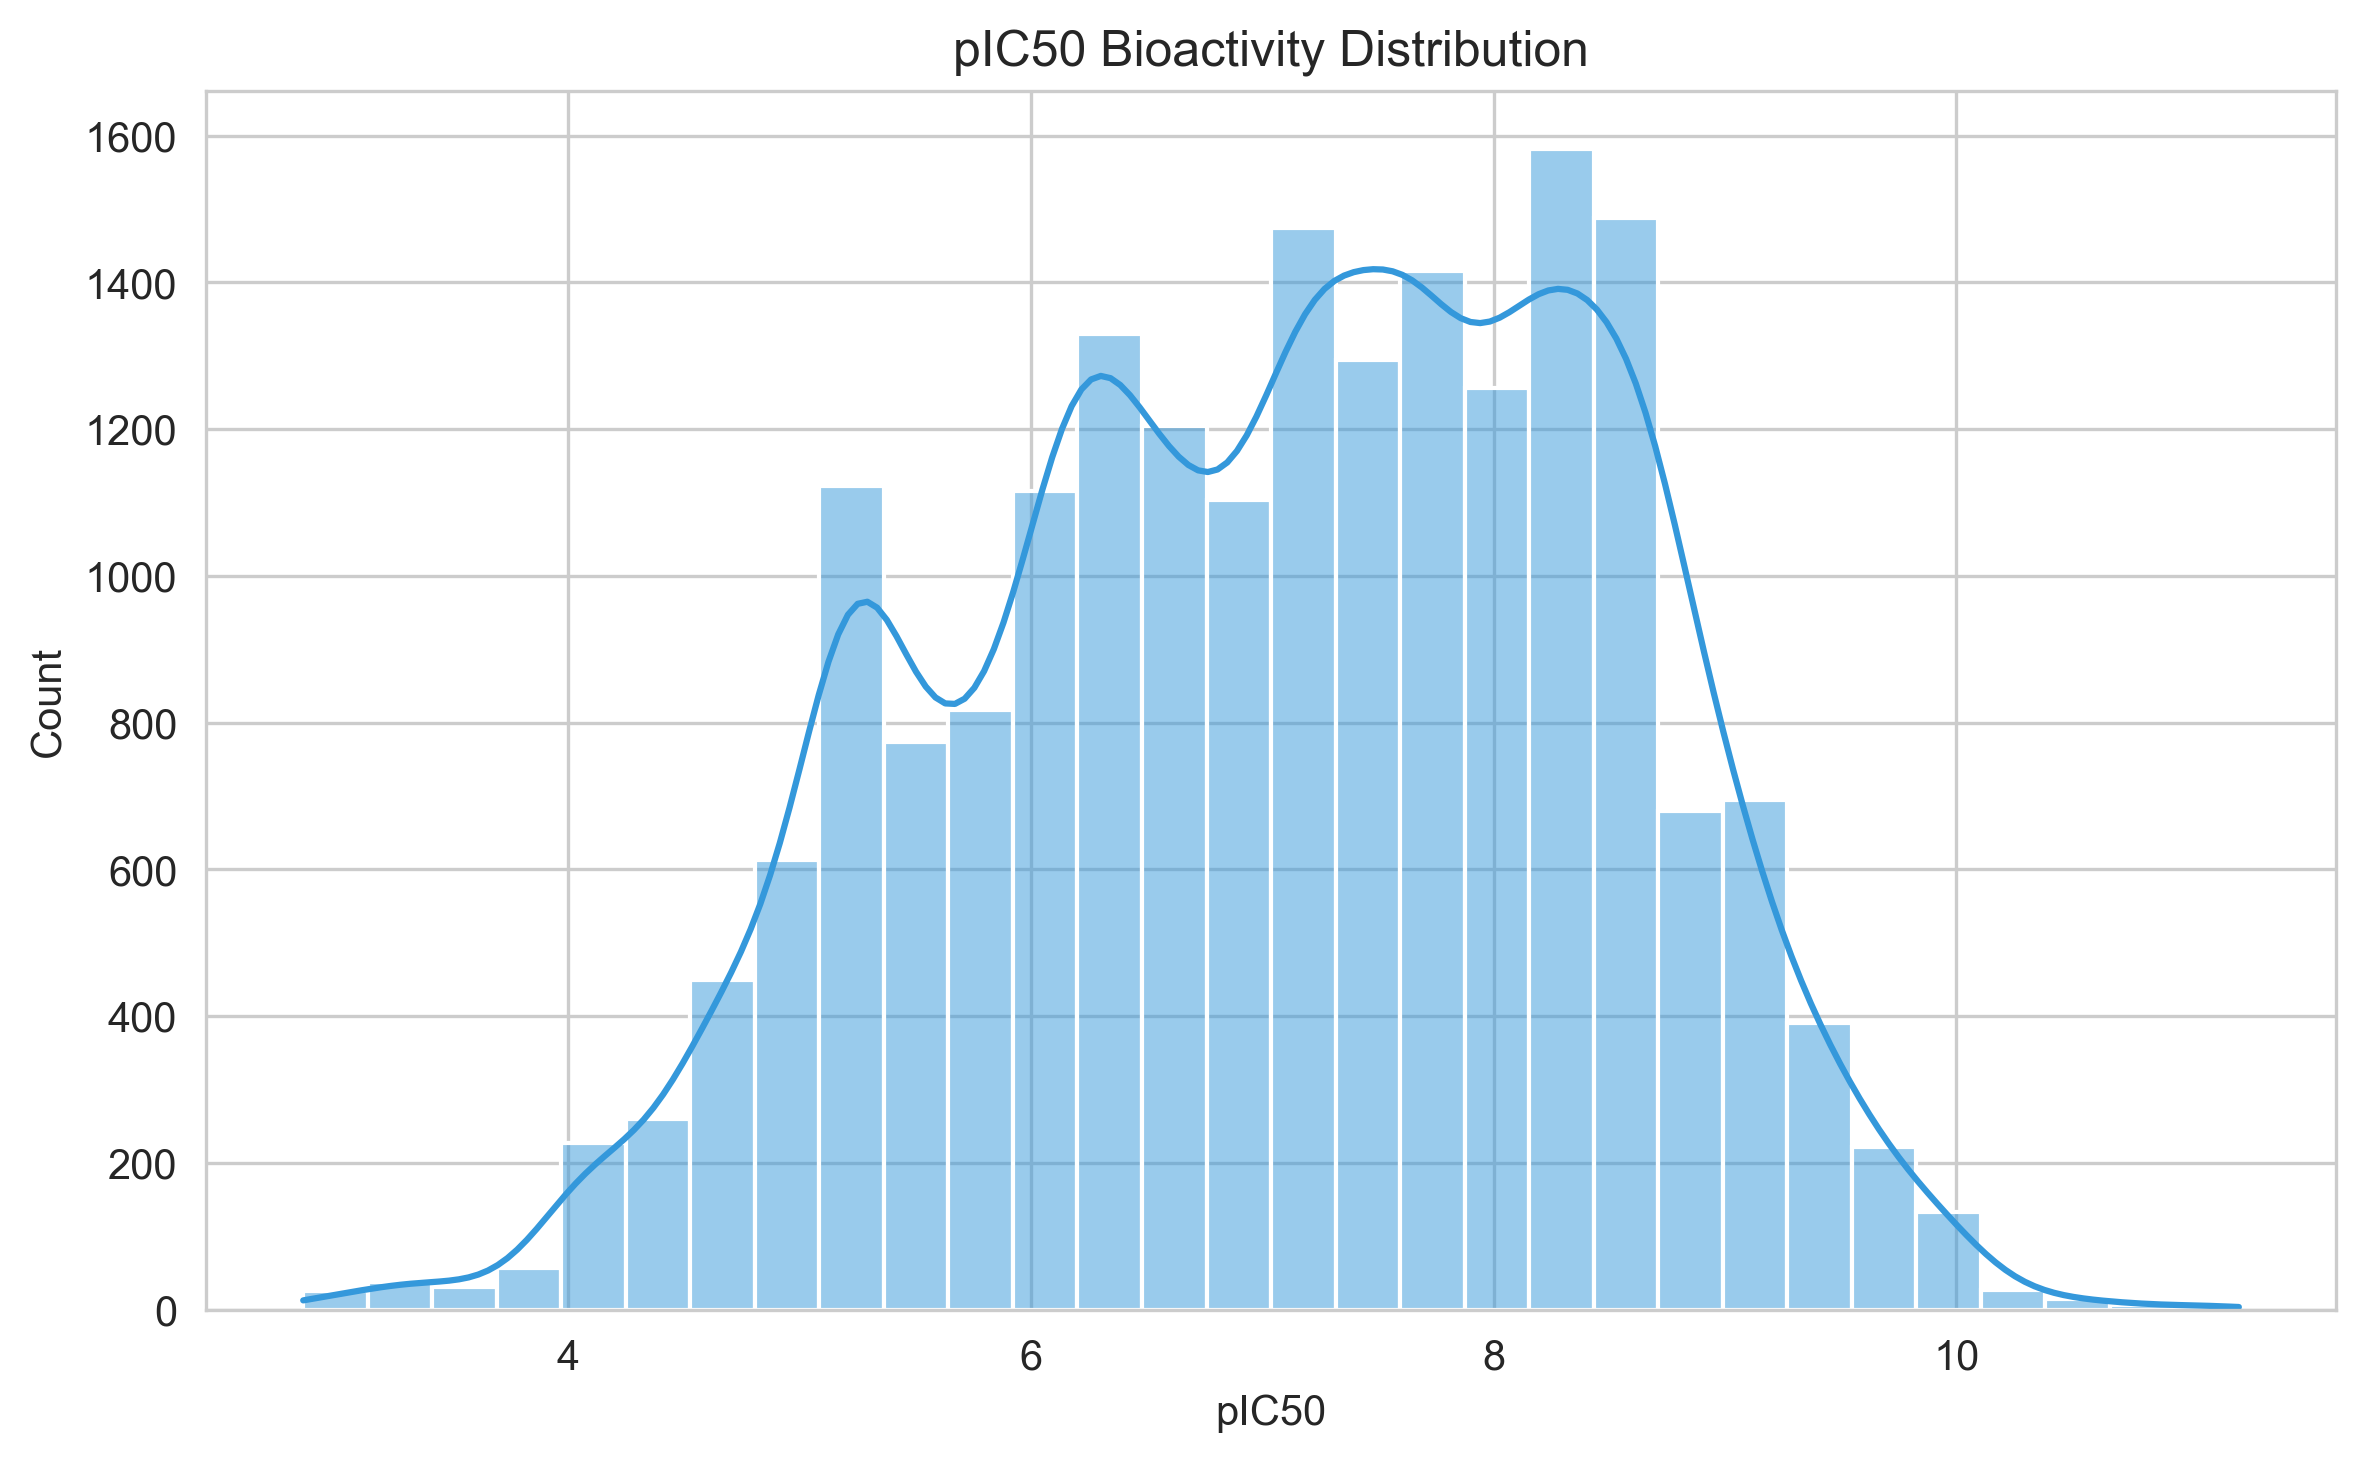


Statistics:
count    19846.000000
mean         7.079571
std          1.393615
min          2.853872
25%          6.060481
50%          7.197227
75%          8.194839
max         11.221849
Name: pIC50, dtype: float64


In [38]:
# Cell 8: pIC50 bioactivity distribution (separate cell)
if 'pIC50' in df_global.columns:
    fig, ax = plt.subplots(figsize=(8,5))
    sns.histplot(df_global['pIC50'].dropna(), kde=True, bins=30, color='#3498db', ax=ax)
    ax.set_title('pIC50 Bioactivity Distribution')
    out_file = OUT / 'pic50_distribution.png'
    plt.tight_layout()
    plt.savefig(out_file, dpi=300, bbox_inches='tight')
    plt.close()
    print(f'Saved: {out_file}')
    show_saved_figure(out_file)
    print('\nStatistics:')
    print(df_global['pIC50'].describe())
else:
    print('No pIC50 column found')

Saved: c:\Users\u2251865\Documents\u2251865\NSCLC_project\clean_data_diss\results\figures\pca_cumulative_variance.png


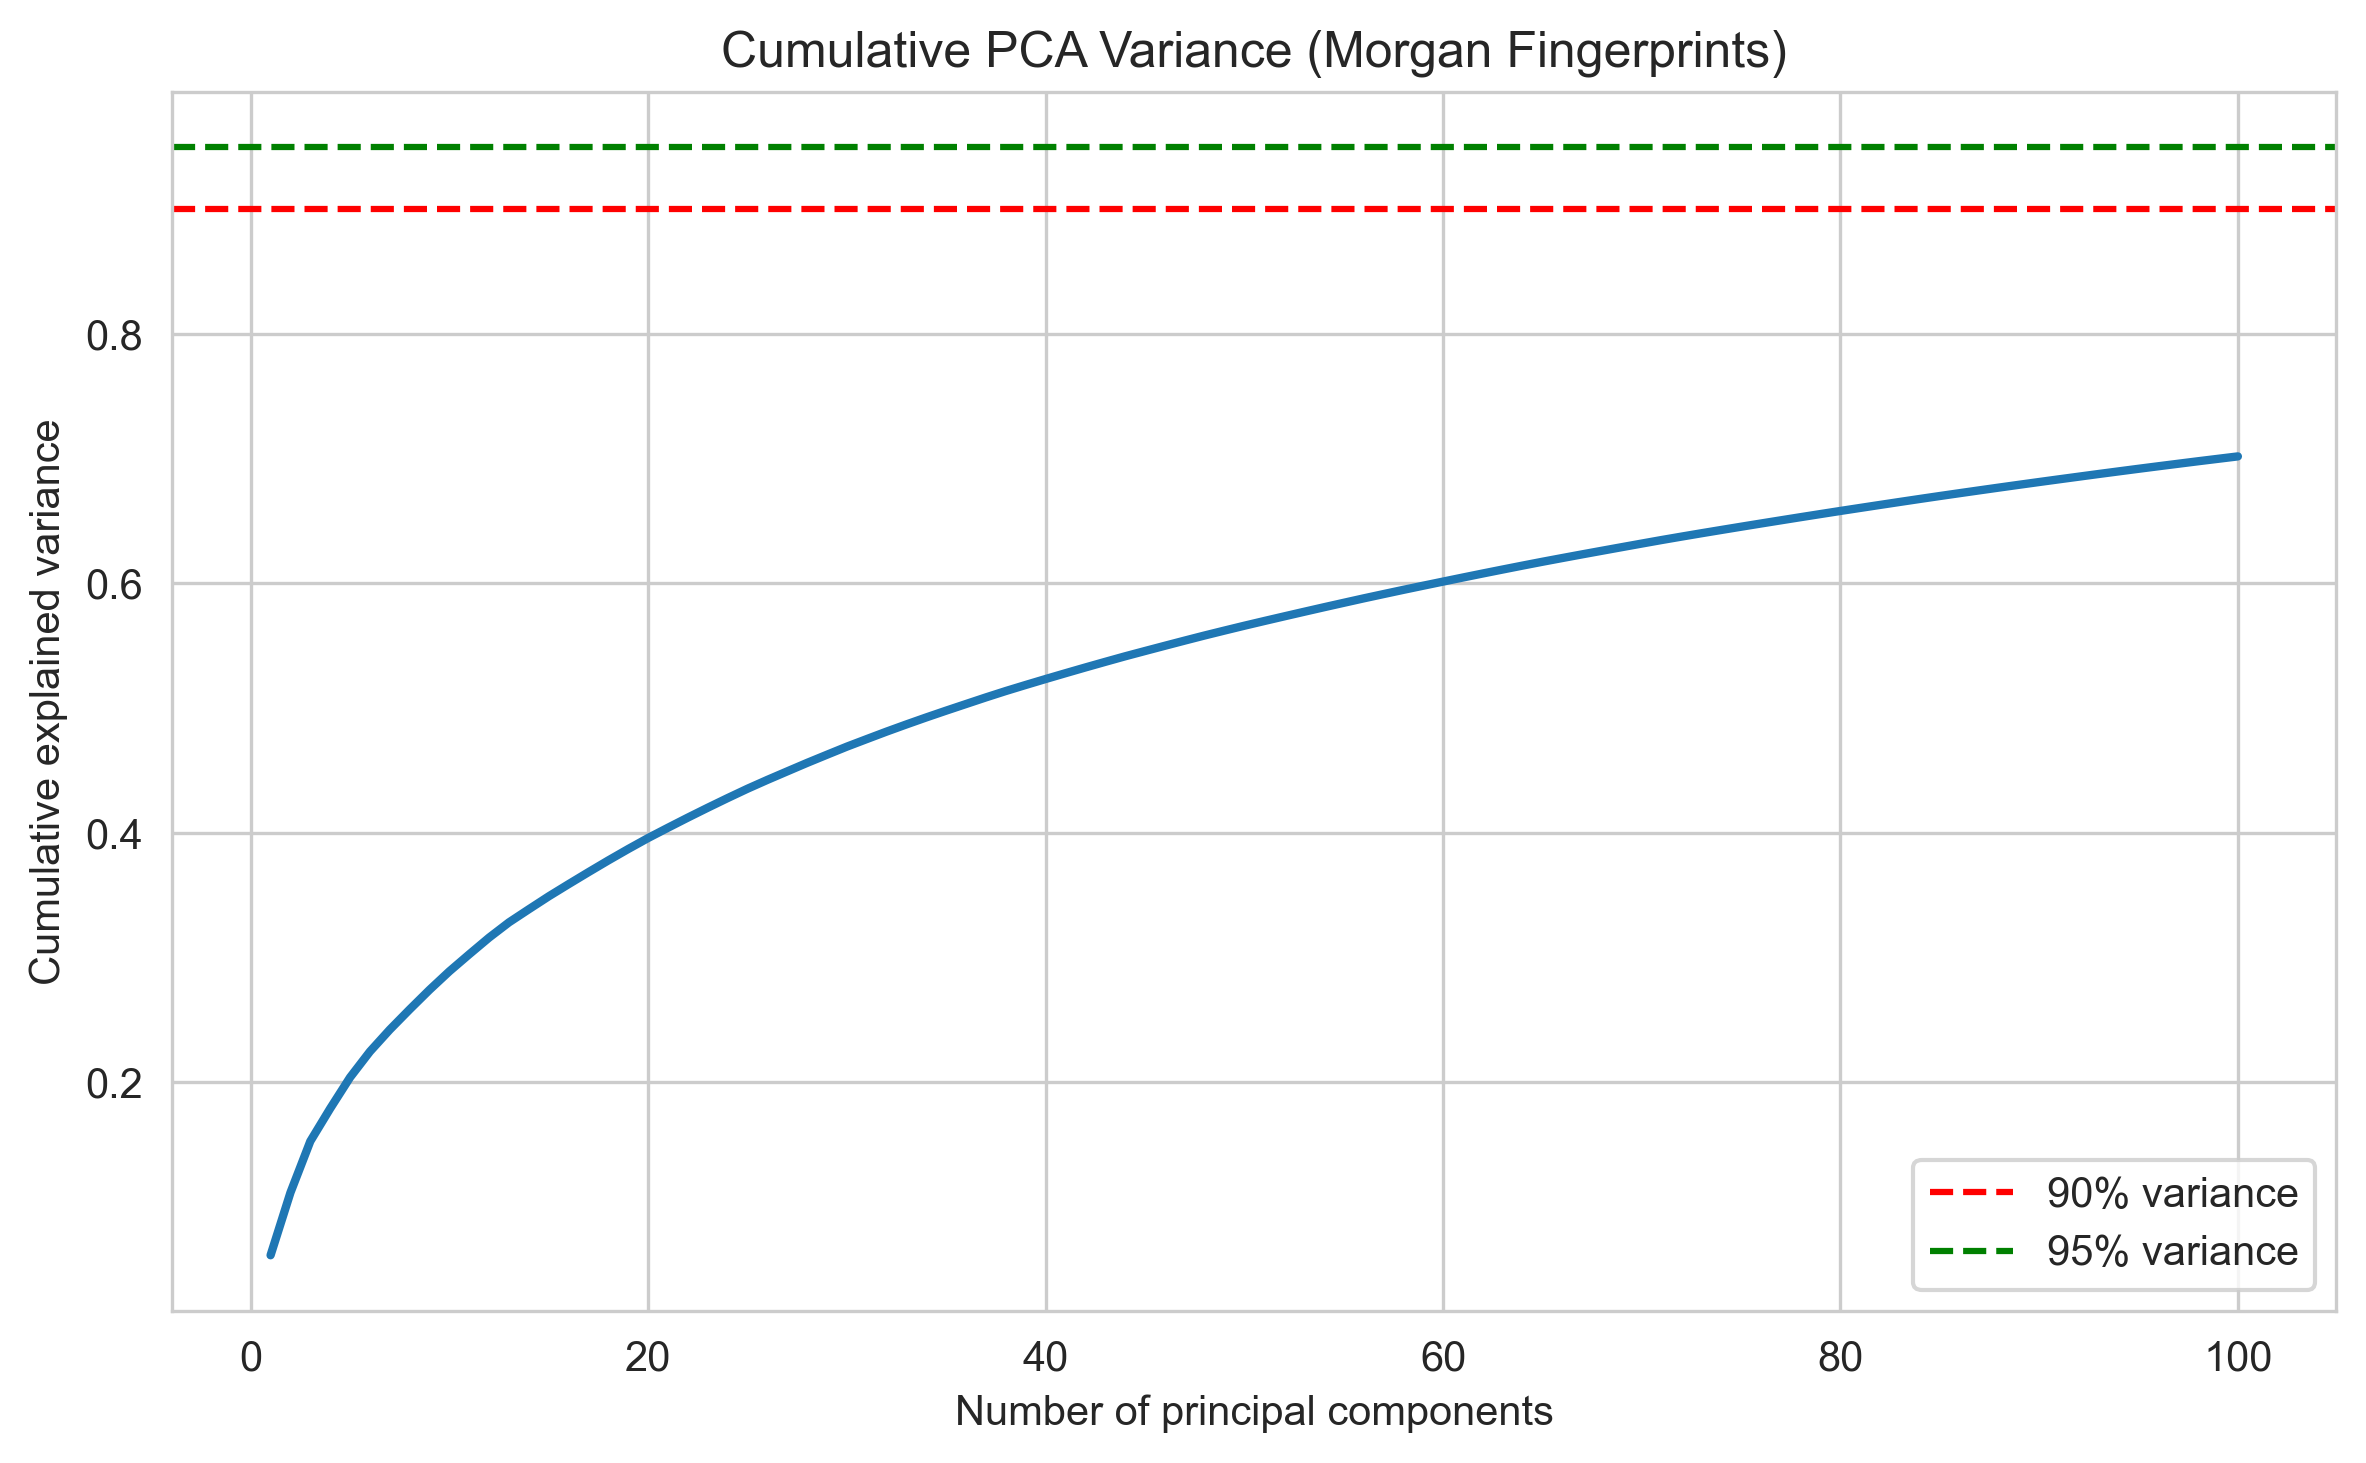

In [39]:
# Cell 9: Cumulative PCA variance (Morgan fingerprints)
if 'fp_array' in globals() and fp_array.shape[0] > 3:
    n_comp = min(100, fp_array.shape[0], fp_array.shape[1])
    pca_full = PCA(n_components=n_comp)
    pca_full.fit(fp_array)
    cum_var = np.cumsum(pca_full.explained_variance_ratio_)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(range(1, len(cum_var) + 1), cum_var, color='#1f77b4', lw=2)
    ax.axhline(0.90, color='red', linestyle='--', label='90% variance')
    ax.axhline(0.95, color='green', linestyle='--', label='95% variance')
    ax.set_xlabel('Number of principal components')
    ax.set_ylabel('Cumulative explained variance')
    ax.set_title('Cumulative PCA Variance (Morgan Fingerprints)')
    ax.legend()
    plt.tight_layout()
    out_file = OUT / 'pca_cumulative_variance.png'
    plt.savefig(out_file, dpi=300, bbox_inches='tight')
    plt.close()
    print(f'Saved: {out_file}')
    show_saved_figure(out_file)
else:
    print('Fingerprint matrix unavailable for PCA variance plot')

Saved: c:\Users\u2251865\Documents\u2251865\NSCLC_project\clean_data_diss\results\figures\morgan_tsne.png


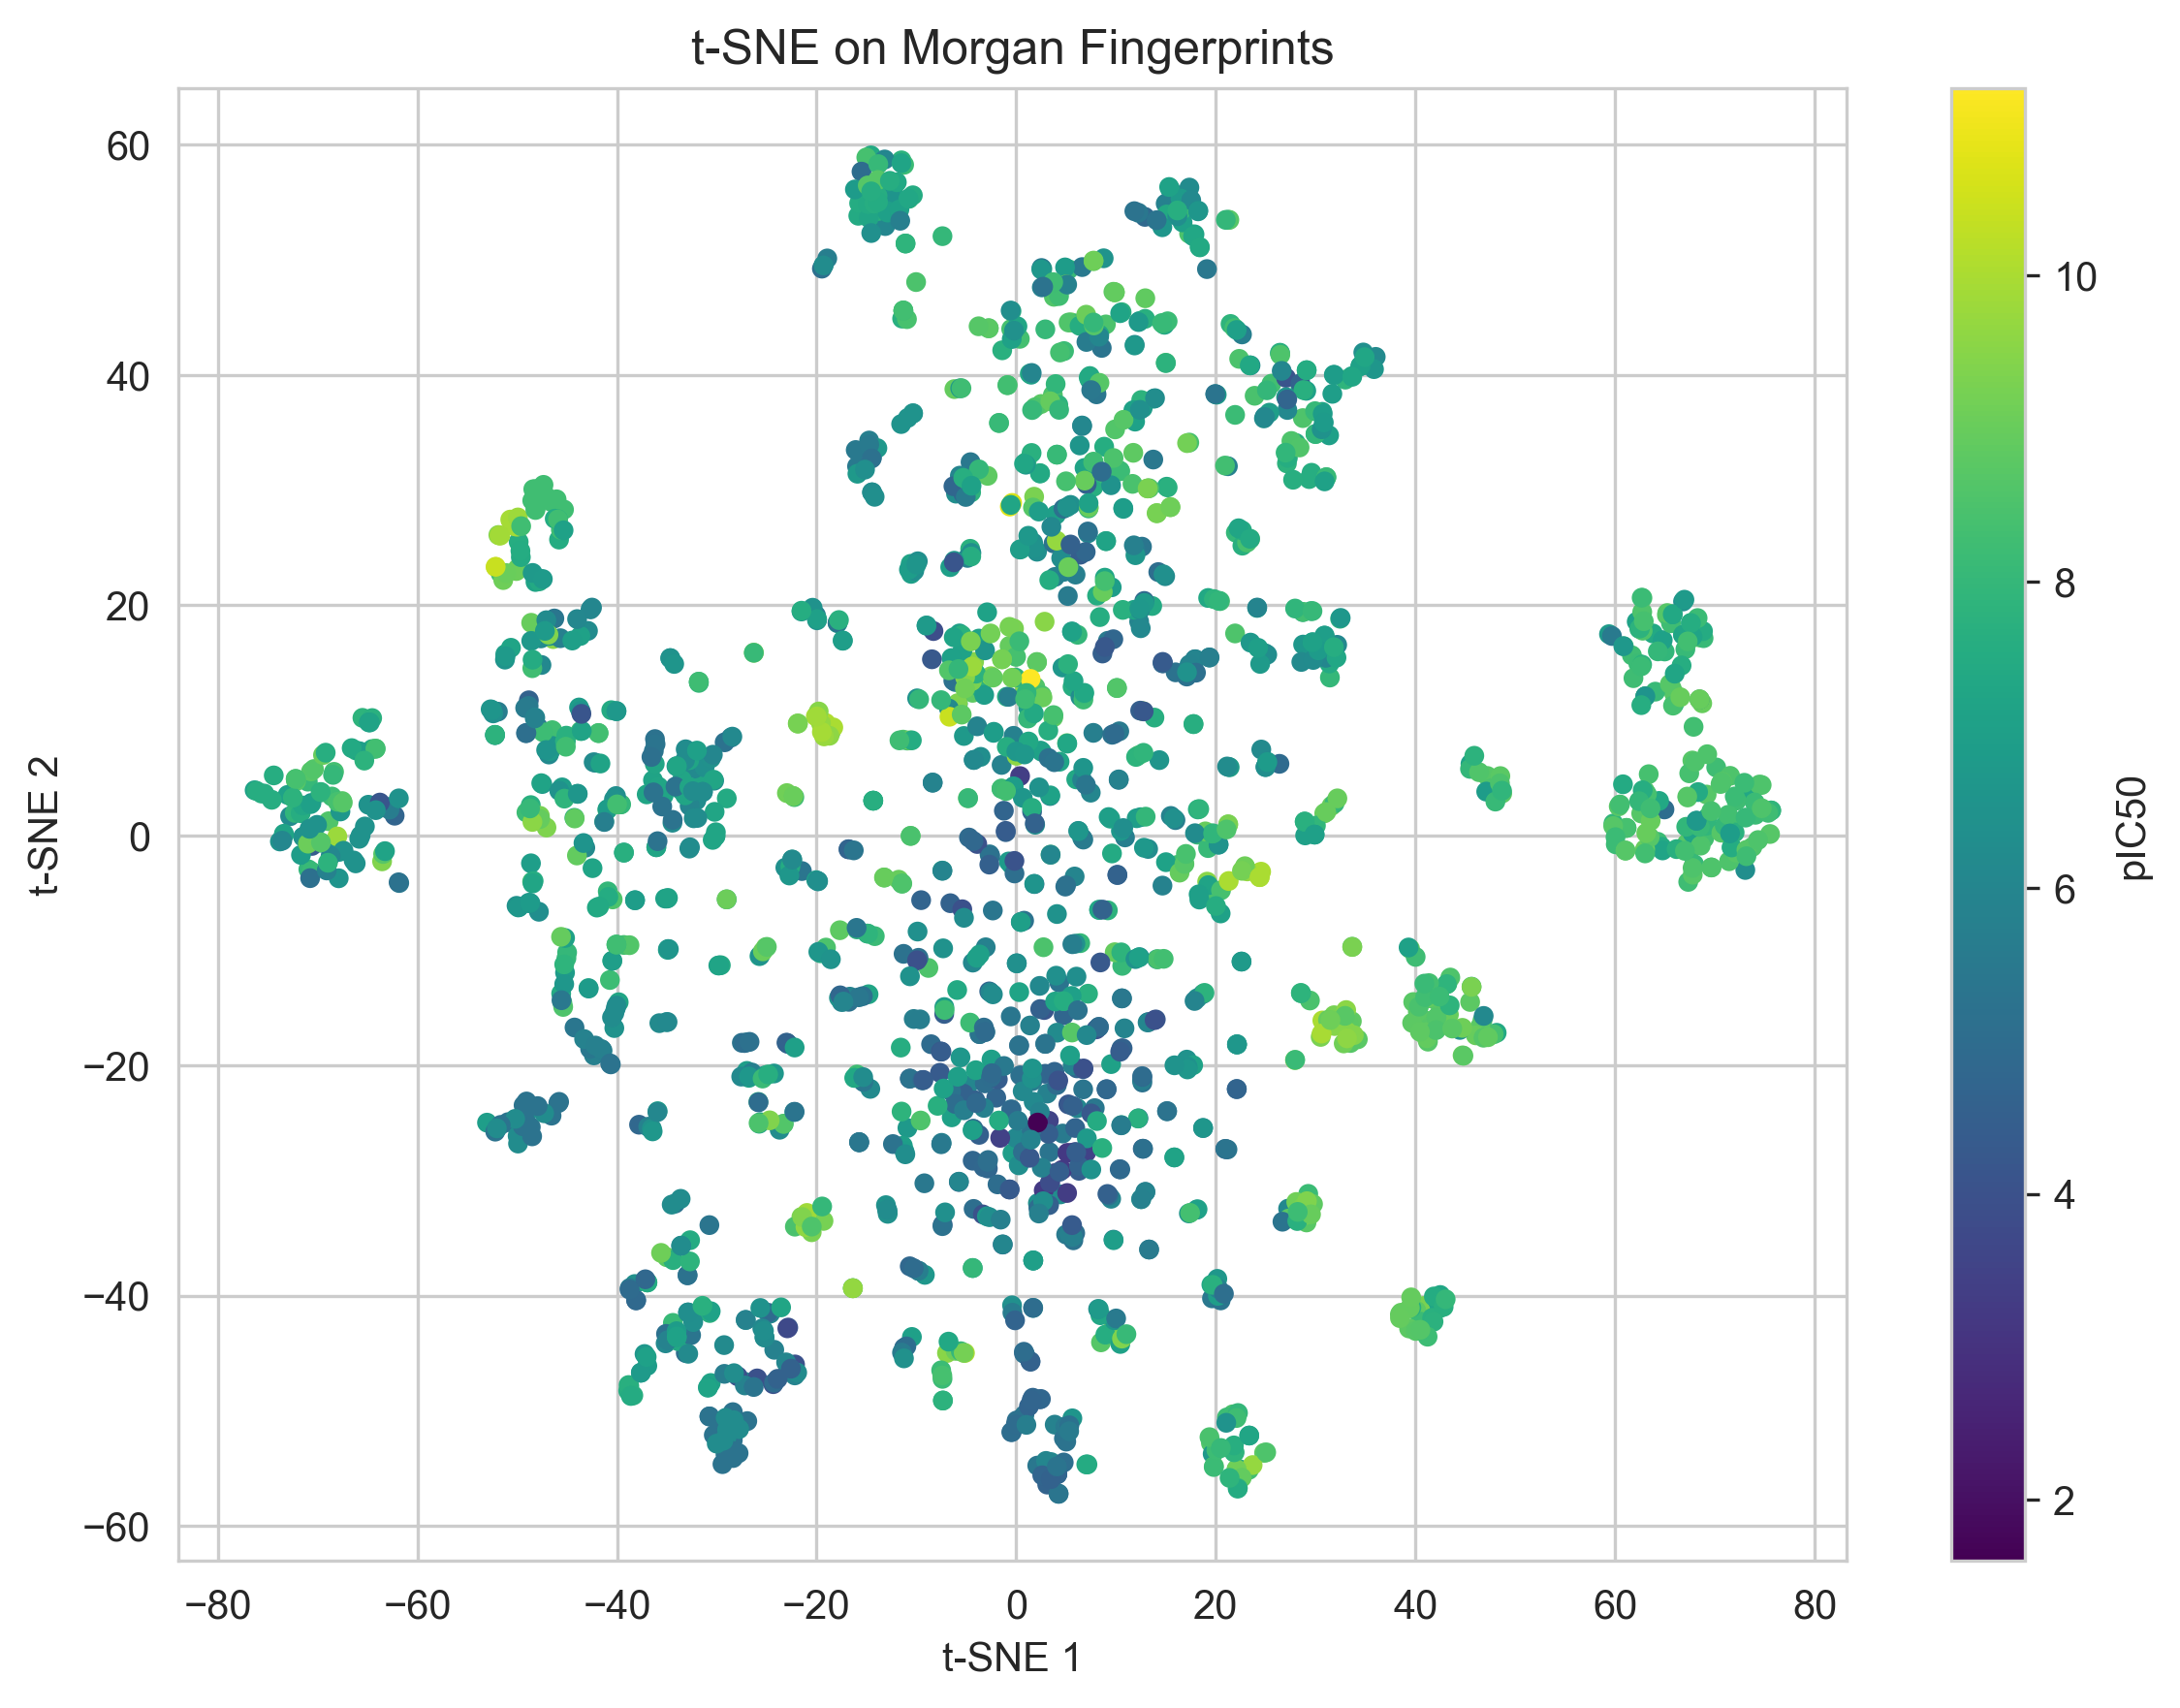

In [40]:
# Cell 10: Morgan fingerprint t-SNE
if 'fp_array' in globals() and fp_array.shape[0] >= 30:
    try:
        from sklearn.manifold import TSNE
        n_samples = fp_array.shape[0]
        perplexity = min(30, max(5, (n_samples - 1) // 3))
        tsne = TSNE(
            n_components=2,
            perplexity=perplexity,
            learning_rate='auto',
            init='pca',
            random_state=SEED,
        )
        ts_coords = tsne.fit_transform(fp_array.astype(np.float32))

        fig, ax = plt.subplots(figsize=(8, 6))
        pic = np.array(valid_pic50, dtype=float) if 'valid_pic50' in globals() else np.full((n_samples,), np.nan)
        mask = np.isfinite(pic)
        if mask.any():
            sc = ax.scatter(ts_coords[mask, 0], ts_coords[mask, 1], c=pic[mask], cmap='viridis', s=24, edgecolors='none')
            plt.colorbar(sc, ax=ax, label='pIC50')
        if (~mask).any():
            ax.scatter(ts_coords[~mask, 0], ts_coords[~mask, 1], c='lightgray', s=18)
        ax.set_title('t-SNE on Morgan Fingerprints')
        ax.set_xlabel('t-SNE 1')
        ax.set_ylabel('t-SNE 2')
        plt.tight_layout()
        out_file = OUT / 'morgan_tsne.png'
        plt.savefig(out_file, dpi=300, bbox_inches='tight')
        plt.close()
        print(f'Saved: {out_file}')
        show_saved_figure(out_file)
    except Exception as e:
        print('t-SNE generation failed:', e)
else:
    print('Insufficient fingerprint samples for t-SNE')

Saved: c:\Users\u2251865\Documents\u2251865\NSCLC_project\clean_data_diss\results\figures\bemis_murcko_scaffold_frequency.png


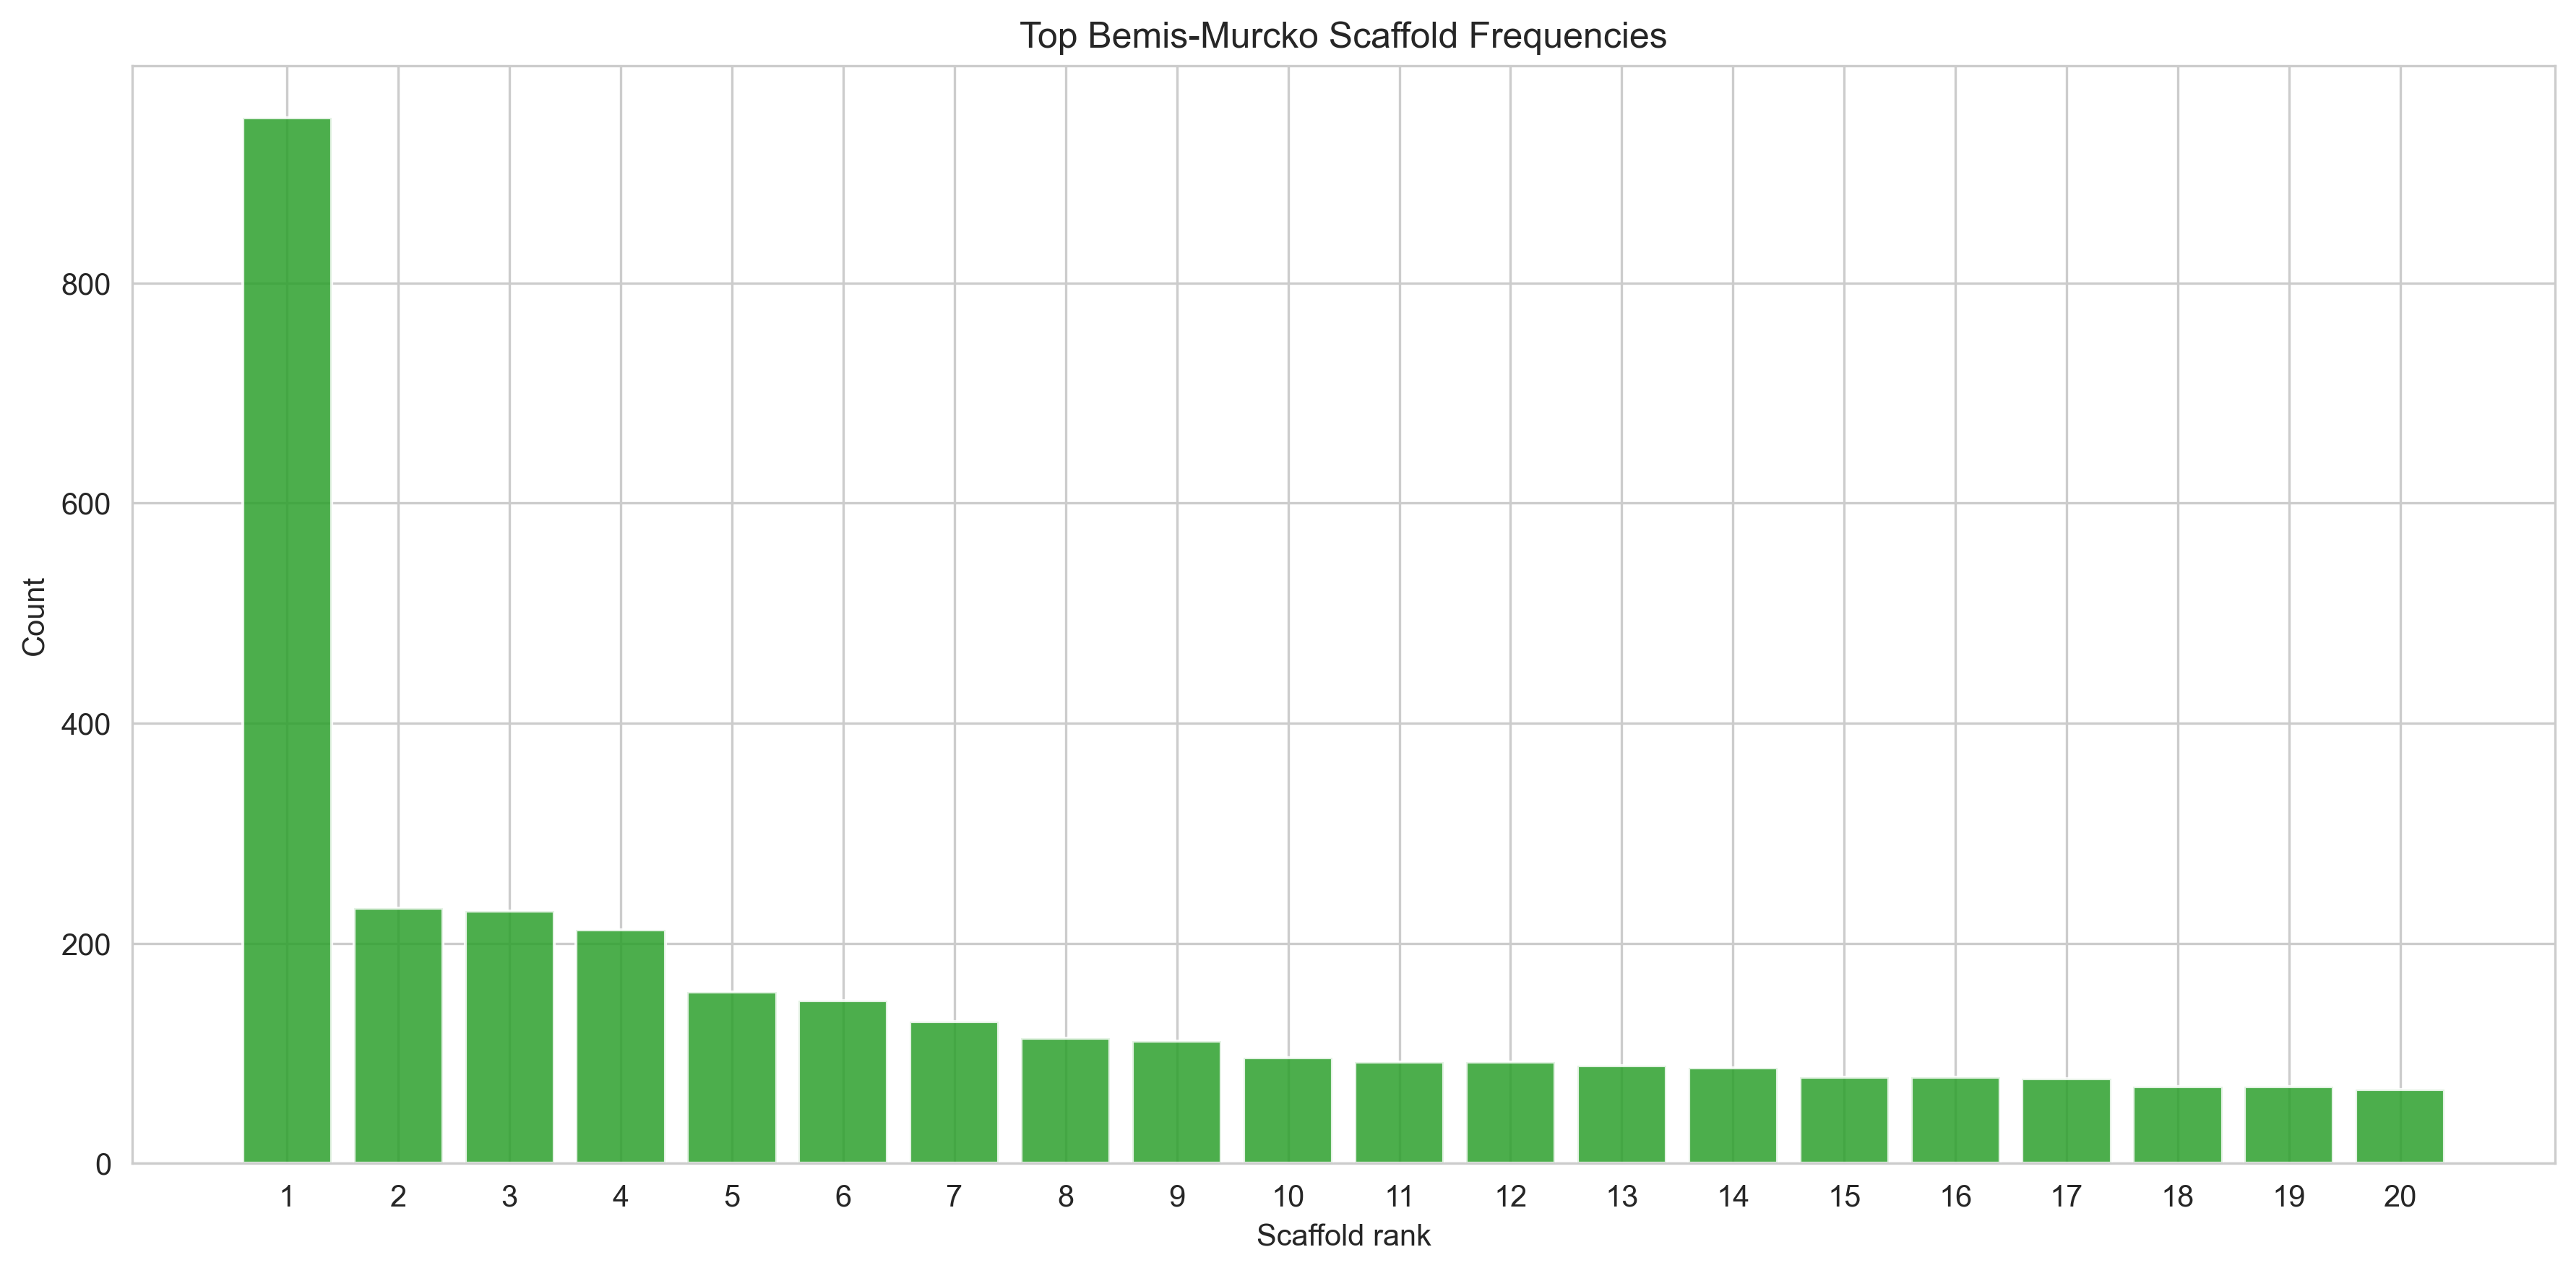

Top 10 scaffold SMILES:
1. c1ccc(Nc2ncnc3ccccc23)cc1 -> 950
2. C1=C(C(Nc2ccc3ncccc3c2)c2cccnc2)NNN1C1CC1 -> 232
3. c1ccc(Nc2ccnc(Nc3ccccc3)n2)cc1 -> 229
4. c1ccc(Nc2nccc(-c3c[nH]c4ccccc34)n2)cc1 -> 212
5. c1ccc(CNc2ncnc3[nH]c(-c4ccccc4)cc23)cc1 -> 156
6. c1ccc(Nc2ccnc3ccccc23)cc1 -> 148
7. c1ccccc1 -> 129
8. c1ccc(Oc2ccnc(Nc3ccc(N4CCNCC4)cc3)n2)cc1 -> 114
9. c1ccc(Nc2ncnc3ccncc23)cc1 -> 111
10. O=C1N(c2ccccc2)Cc2cnc(Nc3ccc(N4CCNCC4)cc3)nc2N1C1CCNC1 -> 96


In [41]:
# Cell 11: Bemis-Murcko scaffold frequency chart
try:
    from rdkit.Chem.Scaffolds import MurckoScaffold
    scaffold_counts = {}
    for s in df_global['SMILES'].dropna().astype(str).tolist():
        m = Chem.MolFromSmiles(s)
        if m is None:
            continue
        scaf = MurckoScaffold.MurckoScaffoldSmiles(mol=m)
        if scaf:
            scaffold_counts[scaf] = scaffold_counts.get(scaf, 0) + 1

    if scaffold_counts:
        top_scaffolds = sorted(scaffold_counts.items(), key=lambda x: x[1], reverse=True)[:20]
        labels = [x[0] for x in top_scaffolds]
        counts = [x[1] for x in top_scaffolds]

        fig, ax = plt.subplots(figsize=(12, 6))
        ax.bar(range(len(counts)), counts, color='#2ca02c', alpha=0.85)
        ax.set_title('Top Bemis-Murcko Scaffold Frequencies')
        ax.set_ylabel('Count')
        ax.set_xlabel('Scaffold rank')
        ax.set_xticks(range(len(counts)))
        ax.set_xticklabels([str(i + 1) for i in range(len(counts))], rotation=0)
        plt.tight_layout()
        out_file = OUT / 'bemis_murcko_scaffold_frequency.png'
        plt.savefig(out_file, dpi=300, bbox_inches='tight')
        plt.close()
        print(f'Saved: {out_file}')
        show_saved_figure(out_file)
        print('Top 10 scaffold SMILES:')
        for i, (scaf, cnt) in enumerate(top_scaffolds[:10], start=1):
            print(f'{i}. {scaf} -> {cnt}')
    else:
        print('No valid scaffolds generated')
except Exception as e:
    print('Scaffold frequency chart failed:', e)

In [14]:
# Cell 12: Top 8 most potent compounds (saved grid + ranked report)
from rdkit.Chem import Draw

try:
    import pubchempy as pcp
except Exception:
    pcp = None


def _lookup_pubchem_label(smiles, fallback_label, max_len=40):
    if pcp is not None:
        try:
            compounds = pcp.get_compounds(smiles, namespace='smiles')
            if compounds:
                compound = compounds[0]
                candidates = []
                for attr in ('iupac_name', 'name'):
                    value = getattr(compound, attr, None)
                    if value:
                        candidates.append(str(value).strip())
                try:
                    synonyms = getattr(compound, 'synonyms', None) or []
                    if synonyms:
                        candidates.extend([str(s).strip() for s in synonyms[:5] if str(s).strip()])
                except Exception:
                    pass
                for candidate in candidates:
                    if candidate:
                        return candidate[:max_len]
        except Exception:
            pass
    mol = Chem.MolFromSmiles(smiles)
    if mol is not None:
        return Chem.MolToSmiles(mol, canonical=True)[:max_len]
    return fallback_label[:max_len]


def _save_grid_image(grid_img, out_file):
    if hasattr(grid_img, 'data') and grid_img.data:
        image_bytes = grid_img.data
        if isinstance(image_bytes, str):
            image_bytes = image_bytes.encode('utf-8')
        elif not isinstance(image_bytes, (bytes, bytearray)):
            image_bytes = bytes(image_bytes)
        out_file.write_bytes(image_bytes)
        return
    if hasattr(grid_img, 'save'):
        grid_img.save(out_file)
        return
    if hasattr(grid_img, 'tobytes') and hasattr(grid_img, 'size'):
        from PIL import Image
        mode = getattr(grid_img, 'mode', 'RGB')
        Image.frombytes(mode, grid_img.size, grid_img.tobytes()).save(out_file)
        return
    raise TypeError(f'Unsupported grid image type: {type(grid_img)}')

if 'pIC50' in df_global.columns and len(df_global) > 0:
    top_n = min(8, len(df_global))
    top_actives = df_global.nlargest(top_n, 'pIC50').copy()

    mols_list = []
    legends_list = []
    chem_data = []

    for rank, (_, row) in enumerate(top_actives.iterrows(), start=1):
        smiles = str(row['SMILES'])
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            continue

        short_name = _lookup_pubchem_label(smiles, f'Compound {rank}')
        mols_list.append(mol)
        legends_list.append(short_name)
        chem_data.append({
            'Rank': rank,
            'Name': short_name,
            'pIC50': float(row['pIC50']),
            'MW': float(row.get('MolWt', np.nan)),
            'LogP': float(row.get('LogP', np.nan)),
            'SMILES': smiles,
        })

    if mols_list:
        grid_img = Draw.MolsToGridImage(
            mols_list,
            molsPerRow=4,
            subImgSize=(200, 200),
            legends=legends_list,
            useSVG=False,
        )
        out_file = OUT / 'top_actives_grid.png'
        _save_grid_image(grid_img, out_file)

        print(f'✓ Saved top actives grid (n={len(mols_list)}): {out_file}')
        print()
        print(f'Top {len(chem_data)} Most Potent Compounds:')
        print('─' * 80)
        for data in chem_data:
            print(f"  {data['Rank']}. {data['Name']}")
            print(f"     pIC50={data['pIC50']:.2f} | MW={data['MW']:.1f} | LogP={data['LogP']:.2f}")
            print(f"     SMILES: {data['SMILES'][:60]}...")
        print('─' * 80)
    else:
        print('⚠ Could not parse SMILES for top actives')
else:
    print('⚠ Insufficient data for top actives visualization')

✓ Saved top actives grid (n=8): c:\Users\u2251865\Documents\u2251865\NSCLC_project\clean_data_diss\results\figures\top_actives_grid.png

Top 8 Most Potent Compounds:
────────────────────────────────────────────────────────────────────────────────
  1. CCOc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OCC
     pIC50=11.22 | MW=388.3 | LogP=4.93
     SMILES: CCOc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OCC...
  2. CNc1cc2c(Nc3cccc(Br)c3)ncnc2cn1
     pIC50=11.10 | MW=330.2 | LogP=3.57
     SMILES: CNc1cc2c(Nc3cccc(Br)c3)ncnc2cn1...
  3. Brc1cccc(Nc2ncnc3cc4[nH]cnc4cc23)c1
     pIC50=11.10 | MW=340.2 | LogP=4.01
     SMILES: Brc1cccc(Nc2ncnc3cc4[nH]cnc4cc23)c1...
  4. COc1cc(N2CCC(N(C)C)CC2)ccc1Nc1ncc(C(=O)O
     pIC50=11.10 | MW=562.7 | LogP=6.13
     SMILES: COc1cc(N2CCC(N(C)C)CC2)ccc1Nc1ncc(C(=O)Oc2ccccc2)c(-c2c[nH]c...
  5. Brc1cccc(Nc2ncnc3cc4nc[nH]c4cc23)c1
     pIC50=11.10 | MW=340.2 | LogP=4.01
     SMILES: Brc1cccc(Nc2ncnc3cc4nc[nH]c4cc23)c1...
  6. COCCOc1cc2ncnc(Nc3cccc(OS(=O)(=O)F)c3)c2
     pIC50=11.05 | M

In [7]:
# Cell 12: Robust Graph Topology Conversion (smiles_to_graph)

from rdkit.Chem import rdDistGeom

def smiles_to_graph(smiles, embed_seed=SEED):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    # Single source molecule for charge/coords: copy + Hs only for geometry/charges
    mol_h = Chem.AddHs(Chem.Mol(mol))
    try:
        params = rdDistGeom.ETKDGv3()
        params.randomSeed = int(embed_seed)
        params.useRandomCoords = False
        res = AllChem.EmbedMolecule(mol_h, params)
        if res != 0:
            AllChem.EmbedMolecule(mol_h, randomSeed=int(embed_seed))
    except Exception:
        pass

    try:
        rdPartialCharges.ComputeGasteigerCharges(mol_h)
    except Exception:
        pass

    # Use heavy-atom coordinates that align to original mol atom indexing
    conf = mol_h.GetConformer() if mol_h.GetNumConformers() > 0 else None
    coords = []
    for i in range(mol.GetNumAtoms()):
        if conf is not None:
            pos = conf.GetAtomPosition(i)
            coords.append([pos.x, pos.y, pos.z])
        else:
            coords.append([0.0, 0.0, 0.0])
    coords = np.asarray(coords, dtype=np.float32)

    def atom_feat(atom_idx):
        a = mol.GetAtomWithIdx(atom_idx)
        ch = 0.0
        try:
            ah = mol_h.GetAtomWithIdx(atom_idx)
            if ah.HasProp('_GasteigerCharge'):
                val = float(ah.GetProp('_GasteigerCharge'))
                if np.isfinite(val):
                    ch = val
        except Exception:
            ch = 0.0

        return [
            float(a.GetAtomicNum()),
            float(a.GetTotalDegree()),
            float(a.GetFormalCharge()),
            float(int(a.GetHybridization())),
            float(a.GetIsAromatic()),
            float(a.GetMass()),
            float(int(a.GetChiralTag())),
            float(ch),
        ]

    x = [atom_feat(i) for i in range(mol.GetNumAtoms())]

    edge_list = []
    edge_attr = []
    for b in mol.GetBonds():
        i = b.GetBeginAtomIdx()
        j = b.GetEndAtomIdx()
        edge_list.append([i, j])
        edge_list.append([j, i])
        bt = b.GetBondType()
        attr = [
            int(bt == Chem.rdchem.BondType.SINGLE),
            int(bt == Chem.rdchem.BondType.DOUBLE),
            int(bt == Chem.rdchem.BondType.TRIPLE),
            int(bt == Chem.rdchem.BondType.AROMATIC),
            int(b.GetStereo() != Chem.rdchem.BondStereo.STEREONONE),
        ]
        edge_attr.extend([attr, attr])

    # Zero-bond safety guard for disconnected/unbonded fragments
    if len(edge_list) == 0:
        edge_index = torch.empty((2, 0), dtype=torch.long)
        edge_attr_t = torch.empty((0, 5), dtype=torch.float32)
    else:
        edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()
        edge_attr_t = torch.tensor(edge_attr, dtype=torch.float32)

    try:
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=1024)
        fp_arr = np.array(list(fp.ToBitString()), dtype=np.int8).astype(np.float32)
    except Exception:
        fp_arr = np.zeros(1024, dtype=np.float32)

    data = Data(
        x=torch.tensor(x, dtype=torch.float32),
        edge_index=edge_index,
        edge_attr=edge_attr_t,
        pos=torch.tensor(coords, dtype=torch.float32),
    )
    data.fingerprint = torch.tensor(fp_arr, dtype=torch.float32)
    return data

print('Cell 12: smiles_to_graph updated (shared molecule flow + zero-bond guard)')

Cell 12: smiles_to_graph updated (shared molecule flow + zero-bond guard)


In [15]:
# Cell 13: Global Feature Packing, Deterministic PDB Mapping, Scaffold Anchors, & Serialization with Metadata
import json
from rdkit.Chem.Scaffolds import MurckoScaffold


def compute_v1_feature_pack(mol, coords_heavy):
    """Compute 20 scalar global features; output is always flat shape [20]."""
    eps = 1e-8
    try:
        rdPartialCharges.ComputeGasteigerCharges(mol)
    except Exception:
        pass

    charges = []
    for a in mol.GetAtoms():
        try:
            if a.HasProp('_GasteigerCharge'):
                v = float(a.GetProp('_GasteigerCharge'))
                if np.isfinite(v):
                    charges.append(v)
        except Exception:
            continue
    charges = np.array(charges, dtype=np.float32) if charges else np.zeros(1, dtype=np.float32)

    if coords_heavy is not None and coords_heavy.shape[0] >= 3 and np.any(coords_heavy != 0):
        centered = coords_heavy - coords_heavy.mean(axis=0, keepdims=True)
        rg = float(np.sqrt(np.mean(np.sum(centered ** 2, axis=1))))
        cov = np.cov(centered.T)
        eig = np.sort(np.maximum(np.linalg.eigvalsh(cov), 0.0))[::-1]
        l1, l2, l3 = float(eig[0]), float(eig[1]), float(eig[2])
        asphericity = float(((l1 - l2) ** 2 + (l2 - l3) ** 2 + (l3 - l1) ** 2) / (2.0 * (l1 + l2 + l3) ** 2 + eps))
        npr1 = float(l3 / (l1 + eps))
        npr2 = float(l2 / (l1 + eps))
    else:
        rg, asphericity, npr1, npr2 = 0.0, 0.0, 0.0, 0.0

    aromatic_atoms = sum(int(a.GetIsAromatic()) for a in mol.GetAtoms())
    hetero_atoms = sum(int(a.GetAtomicNum() not in (1, 6)) for a in mol.GetAtoms())

    feats = [
        float(Descriptors.MolWt(mol)),
        float(Crippen.MolLogP(mol)),
        float(Descriptors.TPSA(mol)),
        float(Descriptors.NumHDonors(mol)),
        float(Descriptors.NumHAcceptors(mol)),
        float(Descriptors.NumRotatableBonds(mol)),
        float(rdMolDescriptors.CalcNumRings(mol)),
        float(Lipinski.FractionCSP3(mol)),
        float(mol.GetNumHeavyAtoms()),
        float(hetero_atoms),
        float(hetero_atoms / max(1, mol.GetNumAtoms())),
        float(aromatic_atoms / max(1, mol.GetNumAtoms())),
        float(sum(a.GetFormalCharge() for a in mol.GetAtoms())),
        float(Descriptors.NumValenceElectrons(mol)),
        float(np.mean(charges)),
        float(np.std(charges)),
        rg, asphericity, npr1, npr2,
    ]
    arr = np.array(feats, dtype=np.float32)[:20]
    if arr.size < 20:
        arr = np.pad(arr, (0, 20 - arr.size), 'constant')
    return arr


def scaffold_key_from_smiles(smiles):
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        return 'INVALID'
    scaffold = MurckoScaffold.GetScaffoldForMol(mol)
    if scaffold is None:
        return 'EMPTY'
    scaffold_smiles = Chem.MolToSmiles(scaffold, canonical=True)
    return scaffold_smiles if scaffold_smiles else 'EMPTY'


def build_scaffold_metadata(smiles_series):
    scaffold_keys = [scaffold_key_from_smiles(s) for s in smiles_series]
    scaffold_to_indices = {}
    for row_idx, scaffold_key in enumerate(scaffold_keys):
        scaffold_to_indices.setdefault(scaffold_key, []).append(row_idx)

    sorted_scaffolds = sorted(
        scaffold_to_indices.items(),
        key=lambda item: (len(item[1]), item[0]),
    )

    scaffold_id_map = {scaffold_key: scaffold_id for scaffold_id, (scaffold_key, _) in enumerate(sorted_scaffolds)}
    scaffold_count_map = {scaffold_id_map[scaffold_key]: len(indices) for scaffold_key, indices in sorted_scaffolds}

    total_samples = len(scaffold_keys)
    val_target = max(1, int(round(total_samples * 0.2))) if total_samples > 0 else 0
    val_scaffold_ids = []
    val_count = 0
    for scaffold_key, indices in sorted_scaffolds:
        if val_count < val_target:
            scaffold_id = scaffold_id_map[scaffold_key]
            val_scaffold_ids.append(scaffold_id)
            val_count += len(indices)

    scaffold_split_map = {
        scaffold_id_map[scaffold_key]: ('val' if scaffold_id_map[scaffold_key] in val_scaffold_ids else 'train')
        for scaffold_key, _ in sorted_scaffolds
    }

    sample_split_index = [1 if scaffold_id_map[scaffold_key] in val_scaffold_ids else 0 for scaffold_key in scaffold_keys]
    sample_scaffold_id = [scaffold_id_map[scaffold_key] for scaffold_key in scaffold_keys]
    sample_scaffold_weight = [1.0 / scaffold_count_map[scaffold_id] for scaffold_id in sample_scaffold_id]

    return {
        'scaffold_keys': scaffold_keys,
        'scaffold_to_indices': scaffold_to_indices,
        'scaffold_id_map': scaffold_id_map,
        'scaffold_count_map': scaffold_count_map,
        'scaffold_split_map': scaffold_split_map,
        'sample_split_index': sample_split_index,
        'sample_scaffold_id': sample_scaffold_id,
        'sample_scaffold_weight': sample_scaffold_weight,
    }


global_feature_index = [
    'MolWt', 'LogP', 'TPSA', 'NumHDonors', 'NumHAcceptors',
    'NumRotatableBonds', 'NumRings', 'FractionCSP3', 'NumHeavyAtoms',
    'NumHeteroAtoms', 'HeteroAtomFraction', 'AromaticAtomFraction',
    'FormalChargeSum', 'NumValenceElectrons', 'GasteigerMean', 'GasteigerStd',
    'RadiusGyration', 'Asphericity', 'NPR1', 'NPR2',
]

# Build scaffold metadata before graph serialization so weights and split indices are deterministic.
scaffold_meta = build_scaffold_metadata(df['Smiles'].astype(str).tolist())

graphs = []
pocket_store = {}

for pdb_name, ligand_code in PDB_LIGAND_MAP.items():
    pdb_path = PDB_DIR / pdb_name
    if not pdb_path.exists():
        logging.warning(f'PDB not found: {pdb_path}; pocket embedding will be zeros')
        pocket_store[pdb_name] = torch.zeros(128, dtype=torch.float32)
    else:
        pocket_store[pdb_name] = compute_pocket_tensor(
            pdb_path,
            ligand_code,
            cutoff=6.0,
            embedding_dim=128,
        )

for idx, row in df.reset_index(drop=True).iterrows():
    s = str(row['Smiles'])
    g = smiles_to_graph(s)
    if g is None:
        logging.warning(f'Skipping invalid molecule at row {idx}: could not build graph')
        continue

    mol = Chem.MolFromSmiles(s)
    if mol is None:
        logging.warning(f'Skipping invalid molecule at row {idx}: RDKit parse failed after graph build')
        continue

    coords_heavy = g.pos.cpu().numpy() if getattr(g, 'pos', None) is not None else np.zeros((0, 3), dtype=np.float32)
    v1 = compute_v1_feature_pack(mol, coords_heavy)
    if v1.shape != (20,):
        logging.warning(f'Skipping row {idx}: global feature shape mismatch {v1.shape}')
        continue

    scaffold_id = int(scaffold_meta['sample_scaffold_id'][idx])
    scaffold_weight = float(scaffold_meta['sample_scaffold_weight'][idx])
    pocket_embedding = pocket_store.get(resolve_pdb_for_row(row), torch.zeros(128, dtype=torch.float32))

    if pocket_embedding is None or not isinstance(pocket_embedding, torch.Tensor) or pocket_embedding.numel() != 128:
        logging.warning(f'Skipping row {idx}: invalid pocket embedding for scaffold_id={scaffold_id}')
        continue

    # Keep global_features strictly flat shape [20]
    g.global_features = torch.tensor(v1, dtype=torch.float32)
    g.scaffold_id = torch.tensor([scaffold_id], dtype=torch.long)
    g.scaffold_weight = torch.tensor([scaffold_weight], dtype=torch.float32)

    # Deterministic and explicit assignment config (no modulo heuristic)
    mapped_pdb = resolve_pdb_for_row(row)
    g.pocket_embedding = pocket_embedding.clone().detach().to(torch.float32)
    g.assigned_pdb = mapped_pdb
    g.split_index = torch.tensor([int(scaffold_meta['sample_split_index'][idx])], dtype=torch.long)
    g.SMILES = s
    g.orig_index = int(idx)
    graphs.append(g)

out_file = DATA_PROCESSED / 'graph_data.pt'
metadata_file = DATA_PROCESSED / 'graph_data_metadata.json'

sample_split_index = scaffold_meta['sample_split_index']
split_counts = {
    'train': int(sum(1 for v in sample_split_index if v == 0)),
    'val': int(sum(1 for v in sample_split_index if v == 1)),
}

metadata = {
    'dataset_version': 'v2.1.0',
    'n_graphs': len(graphs),
    'n_input_rows': int(len(df)),
    'n_unique_scaffolds': int(len(scaffold_meta['scaffold_id_map'])),
    'pdb_ligand_map': PDB_LIGAND_MAP,
    'assignment_config': {
        'column_candidates': list(PDB_ASSIGNMENT_CONFIG['column_candidates']),
        'default_pdb': PDB_ASSIGNMENT_CONFIG['default_pdb'],
        'allowed_pdbs': sorted(list(PDB_ASSIGNMENT_CONFIG['allowed_pdbs'])),
    },
    'global_feature_index': {i: name for i, name in enumerate(global_feature_index)},
    'fingerprint_bits': 1024,
    'pocket_embedding_dim': 128,
    'radius_cutoff_angstrom': 6.0,
    'seed': int(SEED),
    'scaffold_id_map': {str(k): int(v) for k, v in scaffold_meta['scaffold_id_map'].items()},
    'scaffold_count_map': {str(k): int(v) for k, v in scaffold_meta['scaffold_count_map'].items()},
    'scaffold_split_map': {str(k): str(v) for k, v in scaffold_meta['scaffold_split_map'].items()},
    'sample_split_index': [int(v) for v in sample_split_index],
    'split_counts': split_counts,
}

bundle = {
    'graphs': graphs,
    'metadata': metadata,
}

torch.save(bundle, str(out_file))
with open(metadata_file, 'w', encoding='utf-8') as fh:
    json.dump(metadata, fh, indent=2)

print(f'Cell 13: Saved collated dataset to {out_file}')
print(f'Cell 13: Saved metadata to {metadata_file}')
print('Cell 13: Metadata fields:', sorted(metadata.keys()))
print('Cell 13: Split counts:', split_counts)

if len(graphs) > 0:
    g0 = graphs[0]
    print('Sample graph check:')
    print(' - num nodes:', g0.num_nodes)
    print(' - x shape:', tuple(g0.x.shape) if getattr(g0, 'x', None) is not None else None)
    print(' - global_features shape:', tuple(g0.global_features.shape) if getattr(g0, 'global_features', None) is not None else None)
    print(' - pocket_embedding shape:', tuple(g0.pocket_embedding.shape) if getattr(g0, 'pocket_embedding', None) is not None else None)
    print(' - scaffold_id shape:', tuple(g0.scaffold_id.shape) if getattr(g0, 'scaffold_id', None) is not None else None)
    print(' - scaffold_weight shape:', tuple(g0.scaffold_weight.shape) if getattr(g0, 'scaffold_weight', None) is not None else None)
    print(' - split_index:', int(g0.split_index.item()) if getattr(g0, 'split_index', None) is not None else None)
    print(' - assigned_pdb:', getattr(g0, 'assigned_pdb', 'NA'))
else:
    print('No graphs created; check input SMILES or earlier errors')

[1M17.pdb] HETATM total=49 | match(AQ4)=29 | non-water HETATM=29
[1M17.pdb] ligand centroid=[22.013999938964844, 0.2529999911785126, 52.79399871826172] | ligand atoms=29
[1M17.pdb] pocket atoms=141 | rel-distance range=(0.612, 13.047)
[2ITY.pdb] HETATM total=50 | match(IRE)=31 | non-water HETATM=31
[2ITY.pdb] ligand centroid=[-50.505001068115234, -0.7300000190734863, -21.565000534057617] | ligand atoms=31
[2ITY.pdb] pocket atoms=155 | rel-distance range=(1.101, 13.064)
[3IKA.pdb] HETATM total=183 | match(WZ4)=0 | non-water HETATM=35
[3IKA.pdb] fallback ligand residues=['0UN'] atom_count=35
[3IKA.pdb] ligand centroid=[-11.848999977111816, 16.89699935913086, 31.836000442504883] | ligand atoms=35
[3IKA.pdb] pocket atoms=146 | rel-distance range=(0.987, 11.502)
[3W2S.pdb] HETATM total=100 | match(GFT)=0 | non-water HETATM=50


[14:15:23] DEPRECATION WARNING: please use MorganGenerator
[14:15:23] DEPRECATION WARNING: please use MorganGenerator
[14:15:23] DEPRECATION WARNING: please use MorganGenerator
[14:15:23] DEPRECATION WARNING: please use MorganGenerator
[14:15:23] DEPRECATION WARNING: please use MorganGenerator


[3W2S.pdb] fallback ligand residues=['W2R'] atom_count=40
[3W2S.pdb] ligand centroid=[5.066999912261963, 1.1109999418258667, 10.348999977111816] | ligand atoms=40
[3W2S.pdb] pocket atoms=221 | rel-distance range=(1.282, 13.966)
[6LUD.pdb] HETATM total=90 | match(9KC)=0 | non-water HETATM=37
[6LUD.pdb] fallback ligand residues=['YY3'] atom_count=37
[6LUD.pdb] ligand centroid=[-49.73099899291992, -0.039000000804662704, -18.219999313354492] | ligand atoms=37
[6LUD.pdb] pocket atoms=146 | rel-distance range=(1.172, 12.749)


[14:15:23] DEPRECATION WARNING: please use MorganGenerator
[14:15:23] DEPRECATION WARNING: please use MorganGenerator
[14:15:23] DEPRECATION WARNING: please use MorganGenerator
[14:15:23] DEPRECATION WARNING: please use MorganGenerator
[14:15:23] DEPRECATION WARNING: please use MorganGenerator
[14:15:23] DEPRECATION WARNING: please use MorganGenerator
[14:15:23] DEPRECATION WARNING: please use MorganGenerator
[14:15:23] DEPRECATION WARNING: please use MorganGenerator
[14:15:23] DEPRECATION WARNING: please use MorganGenerator
[14:15:23] DEPRECATION WARNING: please use MorganGenerator
[14:15:23] DEPRECATION WARNING: please use MorganGenerator
[14:15:23] DEPRECATION WARNING: please use MorganGenerator
[14:15:23] DEPRECATION WARNING: please use MorganGenerator
[14:15:23] DEPRECATION WARNING: please use MorganGenerator
[14:15:23] DEPRECATION WARNING: please use MorganGenerator
[14:15:23] DEPRECATION WARNING: please use MorganGenerator
[14:15:23] DEPRECATION WARNING: please use MorganGenerat

Cell 13: Saved collated dataset to c:\Users\u2251865\Documents\u2251865\NSCLC_project\clean_data_diss\data\processed\graph_data.pt
Cell 13: Saved metadata to c:\Users\u2251865\Documents\u2251865\NSCLC_project\clean_data_diss\data\processed\graph_data_metadata.json
Cell 13: Metadata fields: ['assignment_config', 'dataset_version', 'fingerprint_bits', 'global_feature_index', 'n_graphs', 'n_input_rows', 'n_unique_scaffolds', 'pdb_ligand_map', 'pocket_embedding_dim', 'radius_cutoff_angstrom', 'sample_split_index', 'scaffold_count_map', 'scaffold_id_map', 'scaffold_split_map', 'seed', 'split_counts']
Cell 13: Split counts: {'train': 15876, 'val': 3970}
Sample graph check:
 - num nodes: 27
 - x shape: (27, 8)
 - global_features shape: (20,)
 - pocket_embedding shape: (128,)
 - scaffold_id shape: (1,)
 - scaffold_weight shape: (1,)
 - split_index: 0
 - assigned_pdb: 1M17.pdb


In [18]:
# Cell 6 (post-serialization): Pocket features summary
print('Pocket embeddings summary:')
for pdb_name, emb in pocket_store.items():
    try:
        arr = emb.numpy() if isinstance(emb, torch.Tensor) else np.array(emb)
        print(f' - {pdb_name}: shape={arr.shape}, mean={arr.mean():.4f}, std={arr.std():.4f}')
        print(f'   first10: {np.array2string(arr.flatten()[:10], precision=4, separator=", ")}')
    except Exception as e:
        print(f' - {pdb_name}: error summarizing embedding: {e}')

Pocket embeddings summary:
 - 1M17.pdb: shape=(128,), mean=-0.0000, std=1.0000
   first10: [-2.638 , -2.4679, -2.1503, -2.0823, -1.9891, -1.8679, -1.7589, -1.6939,
 -1.6562, -1.5973]
 - 2ITY.pdb: shape=(128,), mean=0.0000, std=1.0000
   first10: [-2.7513, -2.3438, -2.2476, -2.1593, -2.1101, -2.0296, -1.8356, -1.7994,
 -1.6828, -1.6141]
 - 3IKA.pdb: shape=(128,), mean=0.0000, std=1.0000
   first10: [-2.4722, -2.3294, -1.9184, -1.8206, -1.7377, -1.7214, -1.6649, -1.6038,
 -1.5747, -1.5602]
 - 3W2S.pdb: shape=(128,), mean=0.0000, std=1.0000
   first10: [-2.5586, -2.2997, -2.1592, -1.9925, -1.9673, -1.8626, -1.7488, -1.6743,
 -1.6231, -1.5505]
 - 6LUD.pdb: shape=(128,), mean=0.0000, std=1.0000
   first10: [-2.3798, -2.1054, -1.9503, -1.8834, -1.8519, -1.8376, -1.7491, -1.6183,
 -1.5958, -1.5613]


Visualizing graph topology for example molecules...
Saved graph structure visualization: c:\Users\u2251865\Documents\u2251865\NSCLC_project\clean_data_diss\results\figures\graph_structure_examples.png


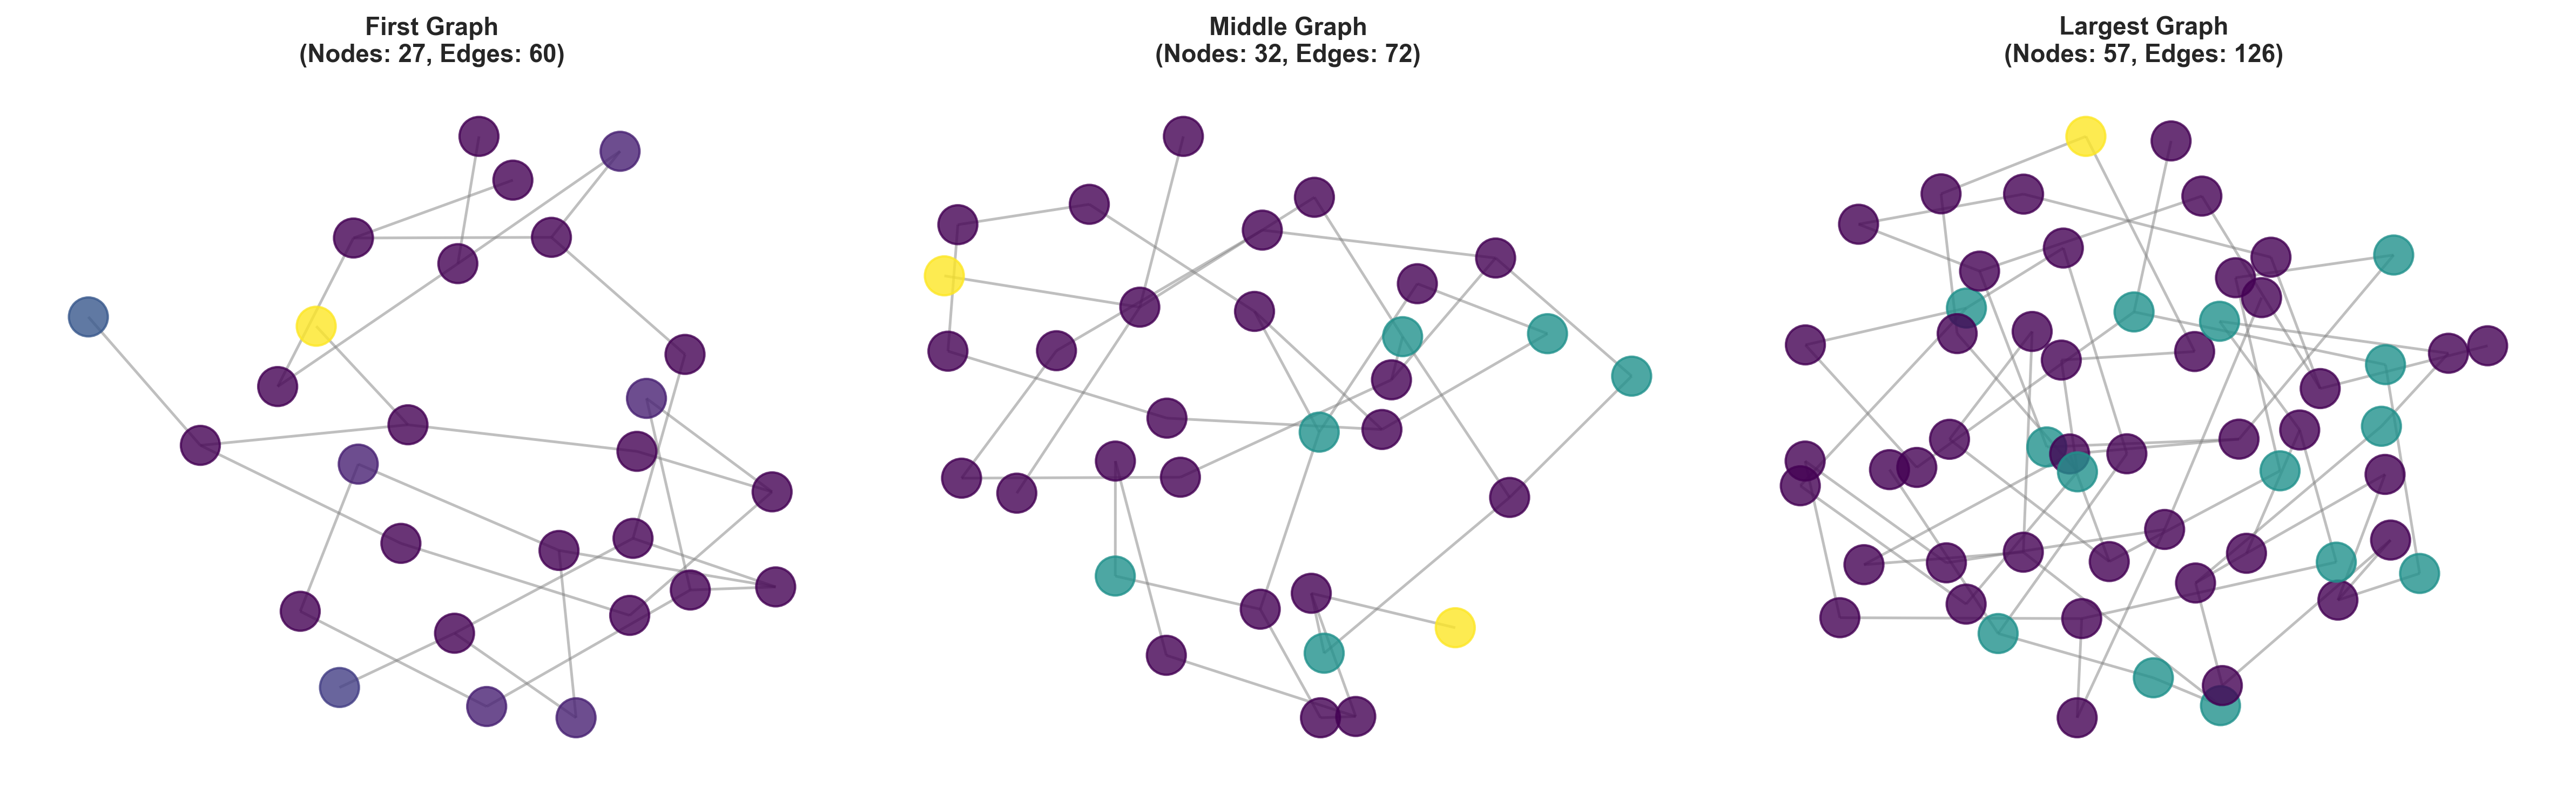

In [17]:
# Cell 7 (post-serialization): Graph structure visualization
from torch_geometric.utils import to_networkx
import networkx as nx

if 'graphs' in globals() and len(graphs) > 2:
    print('Visualizing graph topology for example molecules...')
    idx_first = 0
    idx_middle = len(graphs) // 2
    idx_largest = max(range(len(graphs)), key=lambda i: graphs[i].num_nodes)
    selected_indices = [idx_first, idx_middle, idx_largest]
    selected_graphs = [graphs[i] for i in selected_indices]

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    titles = ['First Graph', 'Middle Graph', 'Largest Graph']
    for ax_idx, (g, title, orig_idx) in enumerate(zip(selected_graphs, titles, selected_indices)):
        edge_index = g.edge_index if getattr(g, 'edge_index', None) is not None else None
        if edge_index is None or (hasattr(edge_index, 'numel') and edge_index.numel() == 0):
            G = nx.Graph()
            G.add_nodes_from(range(g.num_nodes))
        else:
            try:
                G = to_networkx(Data(x=g.x, edge_index=edge_index), to_undirected=True)
            except Exception:
                # Fallback: build edges from tensor
                ei = edge_index.t().tolist() if hasattr(edge_index, 't') else edge_index
                G = nx.Graph()
                G.add_nodes_from(range(g.num_nodes))
                G.add_edges_from(ei)

        pos = nx.spring_layout(G, seed=42, k=0.5, iterations=30)
        if hasattr(g, 'x') and g.x is not None:
            atomic_nums = g.x[:, 0].cpu().numpy().astype(int)
            node_colors = [atomic_nums[i] for i in range(len(atomic_nums))]
        else:
            node_colors = '#87CEEB'

        ax = axes[ax_idx]
        nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=300,
                              cmap='viridis', ax=ax, alpha=0.8)
        nx.draw_networkx_edges(G, pos, width=1.2, alpha=0.5, ax=ax, edge_color='gray')
        ax.set_title(f'{title}\n(Nodes: {g.num_nodes}, Edges: {g.num_edges})', fontweight='bold', fontsize=11)
        ax.axis('off')

    plt.tight_layout()
    graph_viz_out = OUT / 'graph_structure_examples.png'
    plt.savefig(graph_viz_out, dpi=300, bbox_inches='tight')
    plt.close()
    print(f'Saved graph structure visualization: {graph_viz_out}')
    show_saved_figure(graph_viz_out)
else:
    print('Graphs not available for visualization')